# <center><strong>Social Media User Classification</strong></center>
----------------------------------------------------

#### **By Mohamed Jamyl**

http://linkedin.com/company/gray-matter-da

http://linkedin.com/in/mohamed-jamyl

https://www.kaggle.com/mohamedjamyl

https://github.com/Mohamed-Jamyl

-------------------------

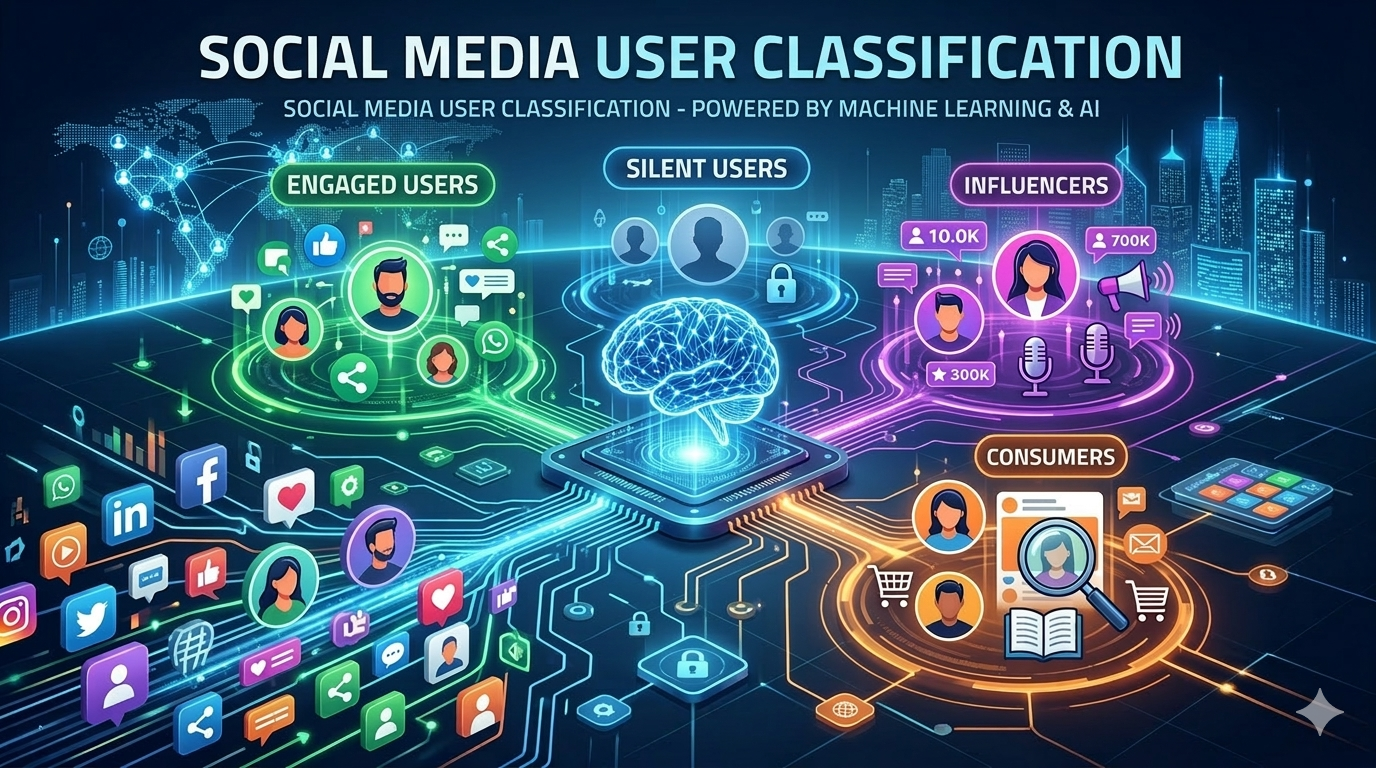

In [1]:
from IPython.display import Image
Image(filename='Logo.png')

--------------------------------
--------------------------------
## **Import Libraries**
--------------------------------

In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import callbacks
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.preprocessing import OneHotEncoder,StandardScaler,OrdinalEncoder

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import pickle
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

2026-03-17 11:37:20.616477: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773747440.801394      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773747440.855771      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773747441.312491      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773747441.312535      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773747441.312538      55 computation_placer.cc:177] computation placer alr

---------------------------------------
---------------------------------------
---------------------------------------

### **Exploring Data**

 - **Data loading and Inspection**
 - **Data Types**
 - **Missing Values**
 - **Duplicates**

-------------------------

In [3]:
df = pd.read_csv('/kaggle/input/datasets/rockyt07/social-media-user-analysis/instagram_users_lifestyle.csv')
df.head()

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,...,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94
4,5,Instagram,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,...,2025-03-19,13.1,Videos,Food,Public,Yes,No,0,Free,1.03


In [4]:
df.shape

(1547896, 58)

In [5]:
df.columns

Index(['user_id', 'app_name', 'age', 'gender', 'country', 'urban_rural',
       'income_level', 'employment_status', 'education_level',
       'relationship_status', 'has_children', 'exercise_hours_per_week',
       'sleep_hours_per_night', 'diet_quality', 'smoking', 'alcohol_frequency',
       'perceived_stress_score', 'self_reported_happiness', 'body_mass_index',
       'blood_pressure_systolic', 'blood_pressure_diastolic',
       'daily_steps_count', 'weekly_work_hours', 'hobbies_count',
       'social_events_per_month', 'books_read_per_year',
       'volunteer_hours_per_month', 'travel_frequency_per_year',
       'daily_active_minutes_instagram', 'sessions_per_day',
       'posts_created_per_week', 'reels_watched_per_day',
       'stories_viewed_per_day', 'likes_given_per_day',
       'comments_written_per_day', 'dms_sent_per_week',
       'dms_received_per_week', 'ads_viewed_per_day', 'ads_clicked_per_day',
       'time_on_feed_per_day', 'time_on_explore_per_day',
       'time_on_

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 58 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   user_id                         1547896 non-null  int64  
 1   app_name                        1547896 non-null  object 
 2   age                             1547896 non-null  int64  
 3   gender                          1547896 non-null  object 
 4   country                         1547896 non-null  object 
 5   urban_rural                     1547896 non-null  object 
 6   income_level                    1547896 non-null  object 
 7   employment_status               1547896 non-null  object 
 8   education_level                 1547896 non-null  object 
 9   relationship_status             1547896 non-null  object 
 10  has_children                    1547896 non-null  object 
 11  exercise_hours_per_week         1547896 non-null  float64
 12  

In [7]:
df.isnull().sum()

user_id                           0
app_name                          0
age                               0
gender                            0
country                           0
urban_rural                       0
income_level                      0
employment_status                 0
education_level                   0
relationship_status               0
has_children                      0
exercise_hours_per_week           0
sleep_hours_per_night             0
diet_quality                      0
smoking                           0
alcohol_frequency                 0
perceived_stress_score            0
self_reported_happiness           0
body_mass_index                   0
blood_pressure_systolic           0
blood_pressure_diastolic          0
daily_steps_count                 0
weekly_work_hours                 0
hobbies_count                     0
social_events_per_month           0
books_read_per_year               0
volunteer_hours_per_month         0
travel_frequency_per_year   

In [8]:
df.duplicated().sum()

np.int64(0)

----------------------------------------------
----------------------------------------------
## **Data Cleaning**
----------------------------------------------

In [9]:
df=df.drop('user_id',axis=1)

In [10]:
df['education_level'].value_counts()

education_level
Bachelor’s      541083
High school     387323
Some college    309922
Master’s        185651
Other            77295
PhD              37003
Secondary         4364
Bachelor          2650
High School       2605
Name: count, dtype: int64

In [11]:
df['education_level'] = df['education_level'].replace('Bachelor’s','Bachelor')
df['education_level'] = df['education_level'].replace('High School','High school')

In [12]:
df['education_level'].value_counts()

education_level
Bachelor        543733
High school     389928
Some college    309922
Master’s        185651
Other            77295
PhD              37003
Secondary         4364
Name: count, dtype: int64

In [13]:
df['smoking'] = df['smoking'].replace('Former','No')

In [14]:
df['smoking'].value_counts()

smoking
No     1314963
Yes     232933
Name: count, dtype: int64

----------------------------------
### **Basic Statistical Overview**
-------------------------------------------
- Summary Statistical : **describe()**
--------------------------------------

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1547896.0,38.985440,15.294528,13.00,26.00,39.0,52.00,65.00
exercise_hours_per_week,1547896.0,7.143480,3.994556,0.00,4.00,6.6,9.70,24.10
sleep_hours_per_night,1547896.0,6.999384,1.097098,3.00,6.30,7.0,7.70,10.00
perceived_stress_score,1547896.0,19.987738,11.832578,0.00,10.00,20.0,30.00,40.00
self_reported_happiness,1547896.0,5.499804,2.871232,1.00,3.00,5.0,8.00,10.00
body_mass_index,1547896.0,25.000837,3.976188,15.00,22.30,25.0,27.70,45.00
blood_pressure_systolic,1547896.0,124.491714,20.206989,90.00,107.00,124.0,142.00,159.00
blood_pressure_diastolic,1547896.0,79.500074,11.548740,60.00,70.00,79.0,90.00,99.00
daily_steps_count,1547896.0,8000.104562,89.397615,7566.00,7940.00,8000.0,8060.00,8473.00
weekly_work_hours,1547896.0,36.222014,15.080632,0.00,30.50,38.7,46.00,80.00


In [16]:
df.select_dtypes('object').describe().T

,count,unique,top,freq
app_name,1547896,1,Instagram,1547896
gender,1547896,4,Male,743169
country,1547896,10,United States,386829
urban_rural,1547896,3,Urban,850754
income_level,1547896,5,Middle,465037
employment_status,1547896,7,Full-time employed,629798
education_level,1547896,7,Bachelor,543733
relationship_status,1547896,5,Single,670260
has_children,1547896,2,No,1156273
diet_quality,1547896,5,Average,543910


---------------------------------------------
## **Detect Outliers**
--------------------------------------------

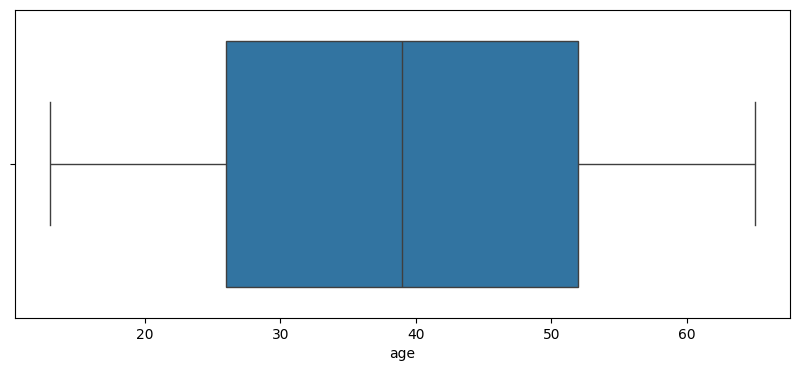

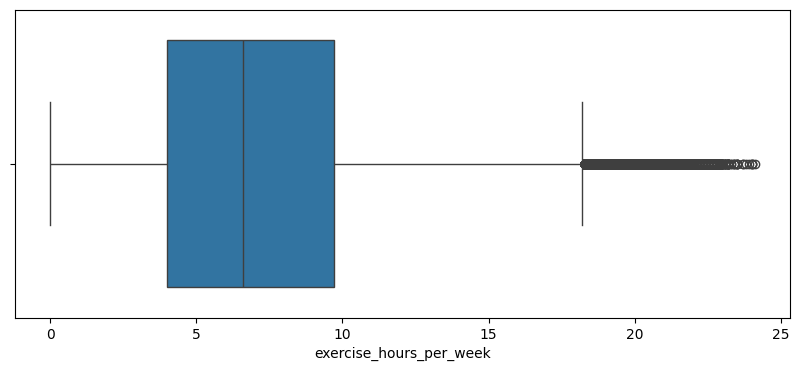

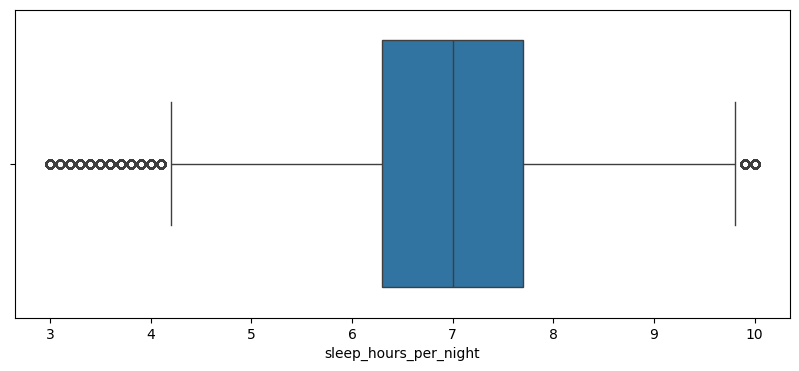

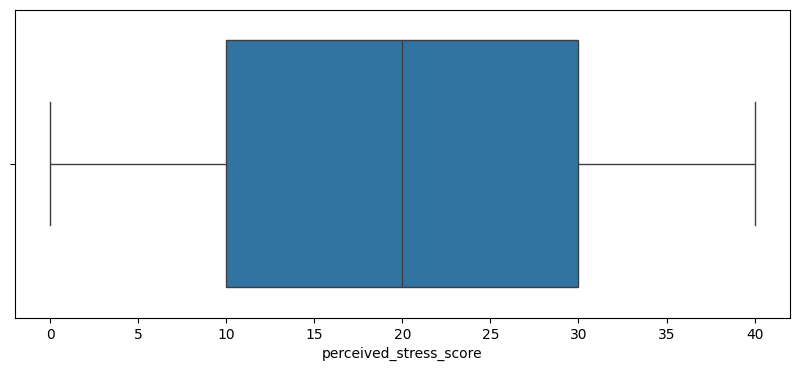

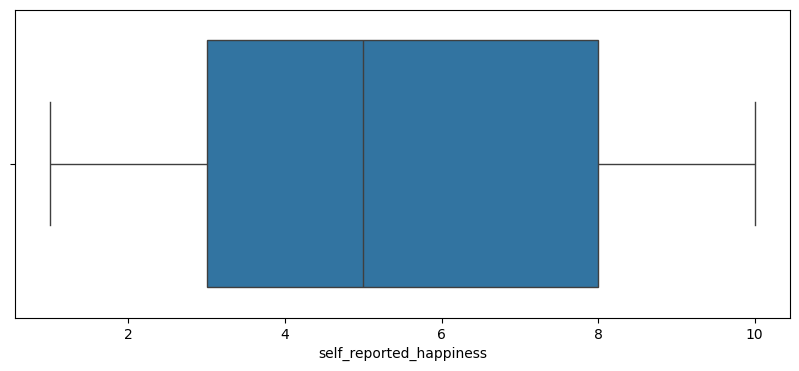

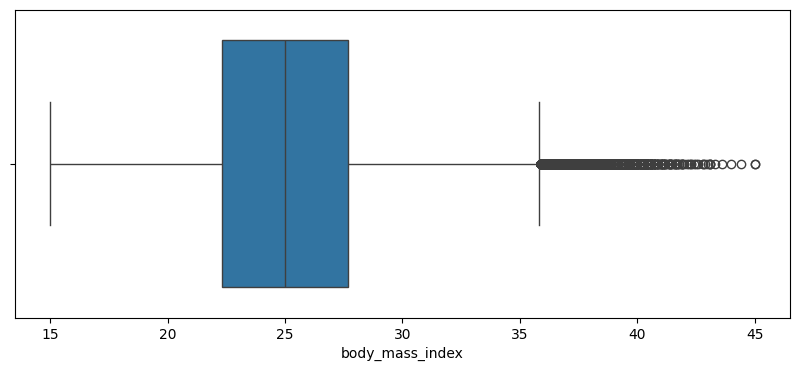

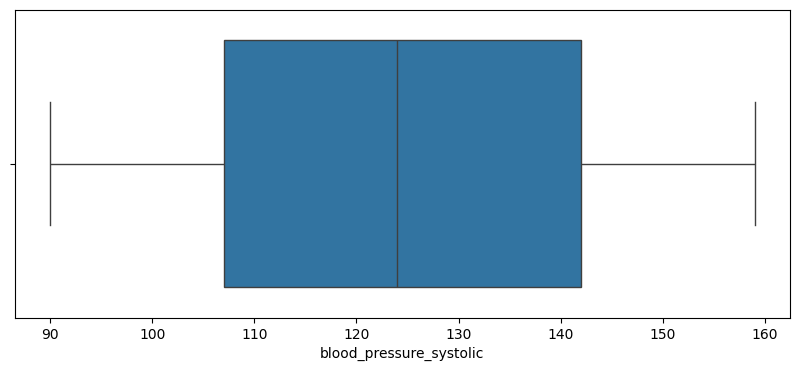

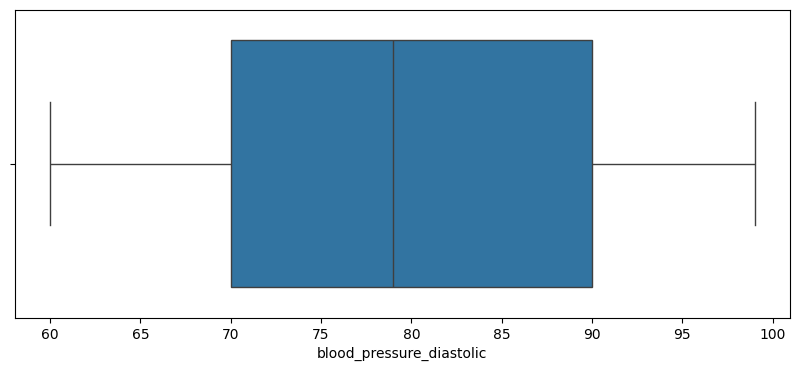

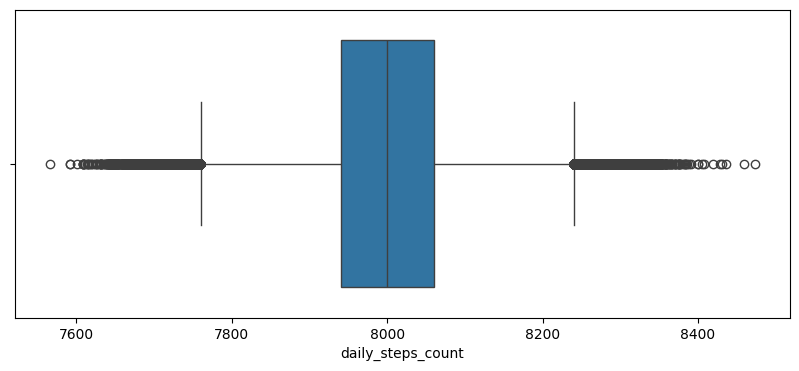

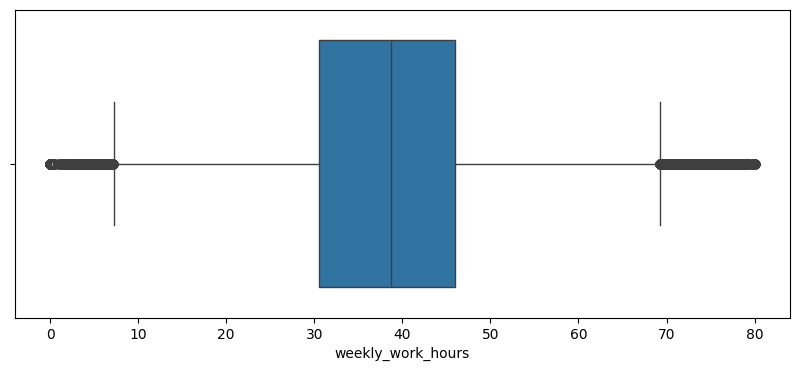

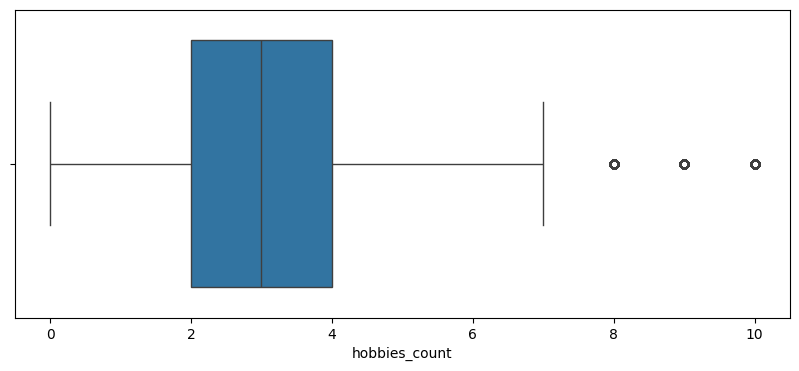

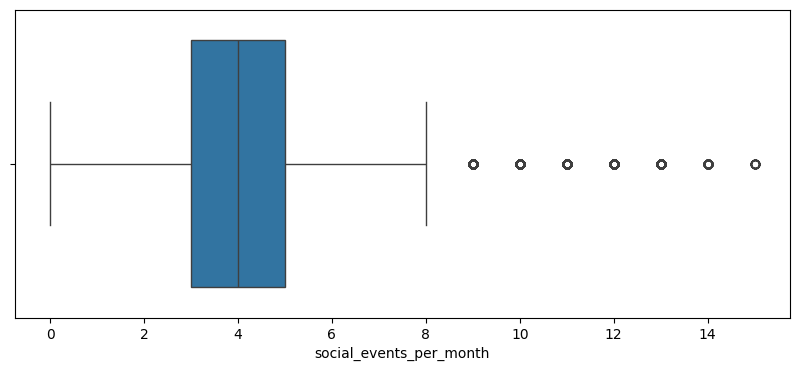

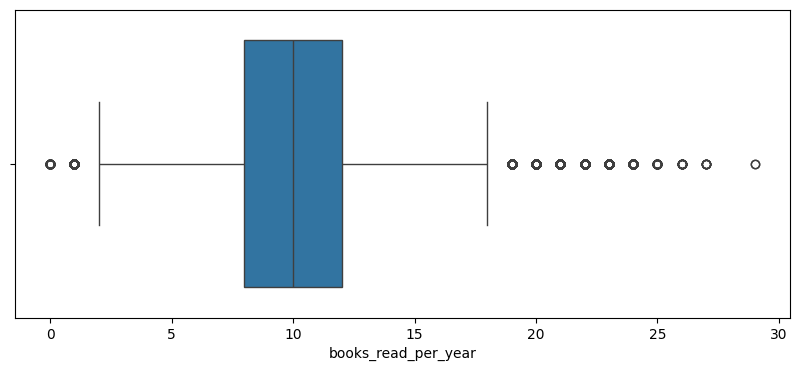

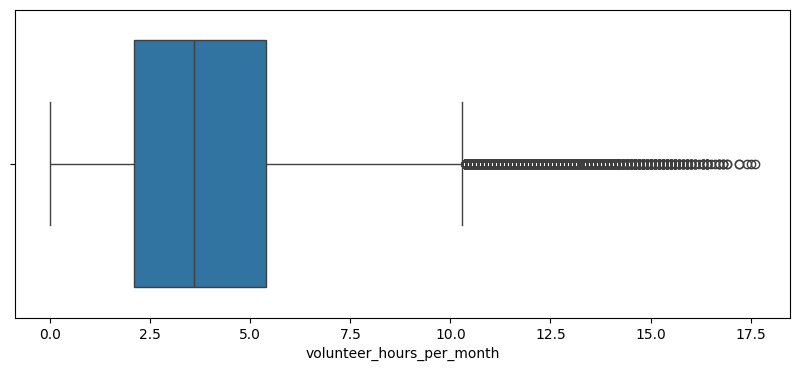

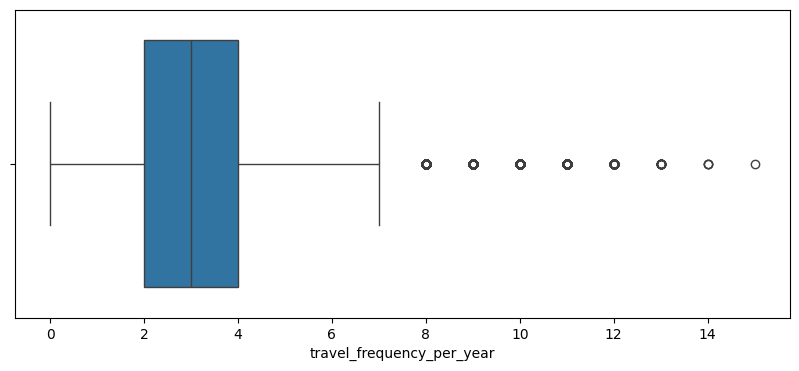

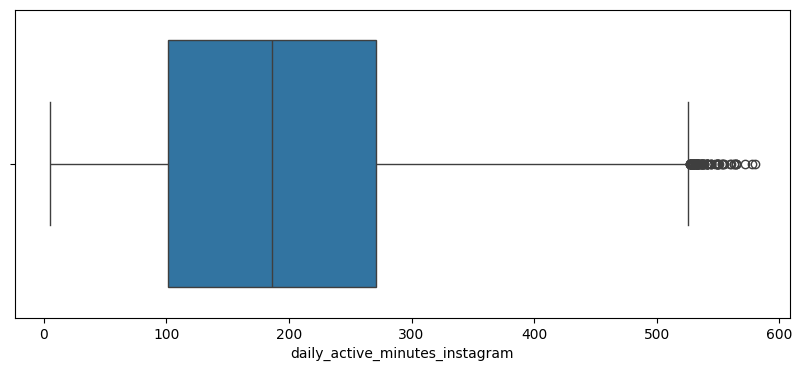

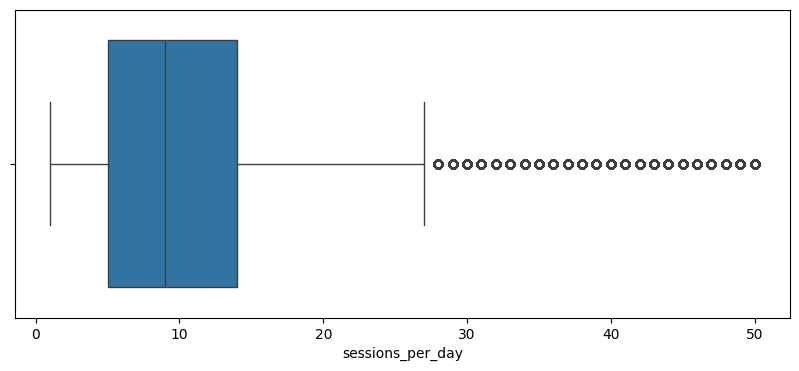

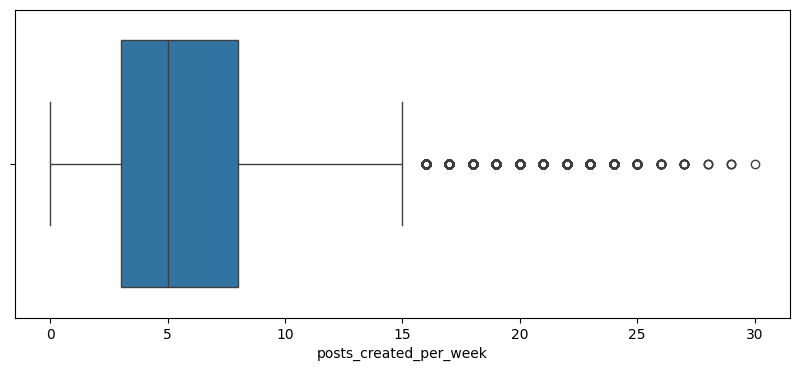

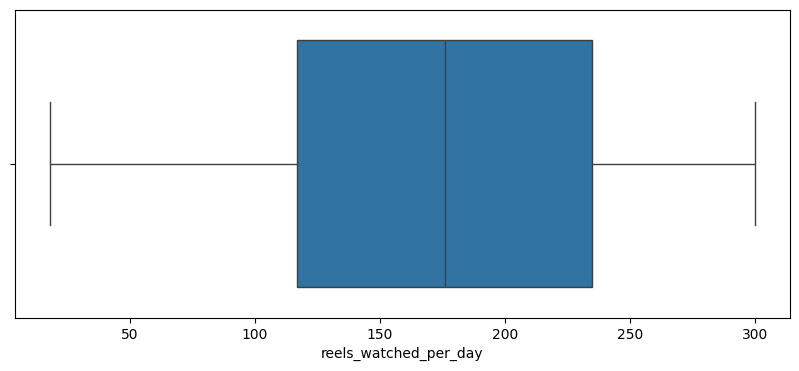

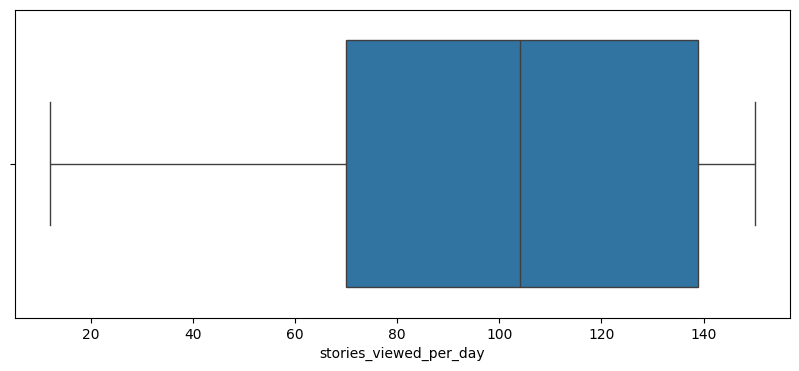

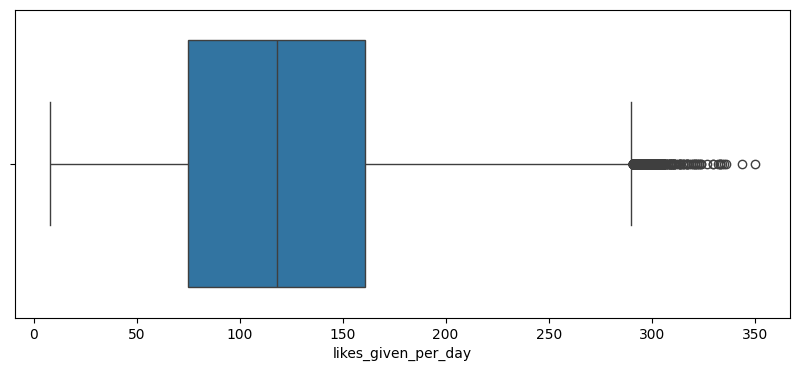

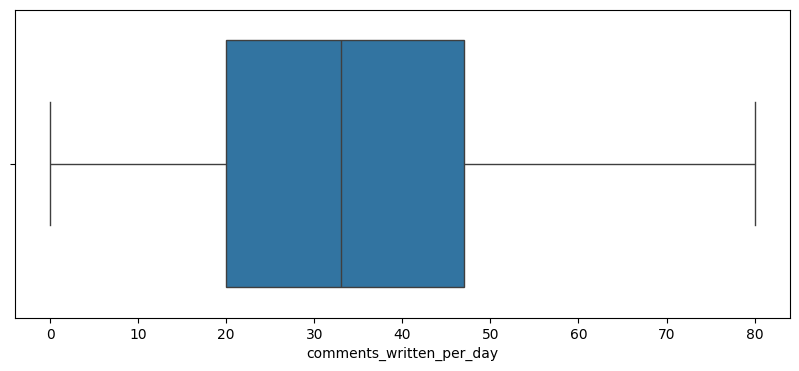

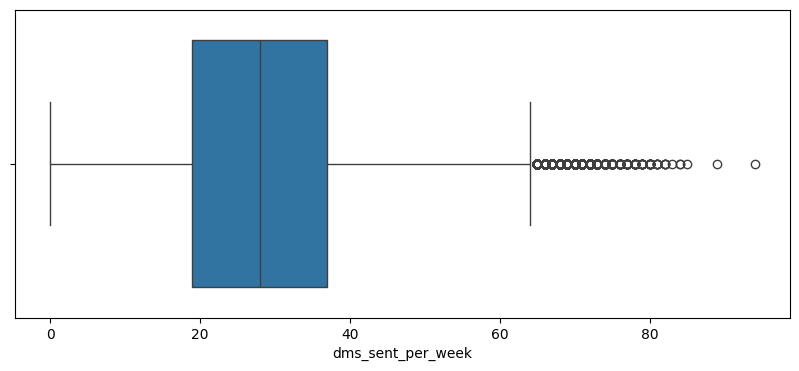

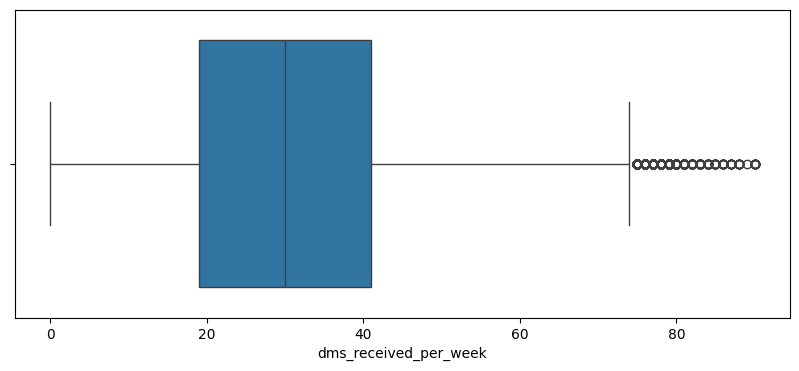

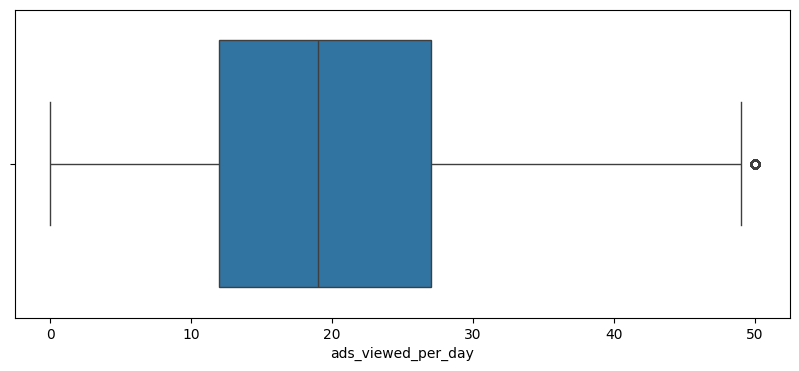

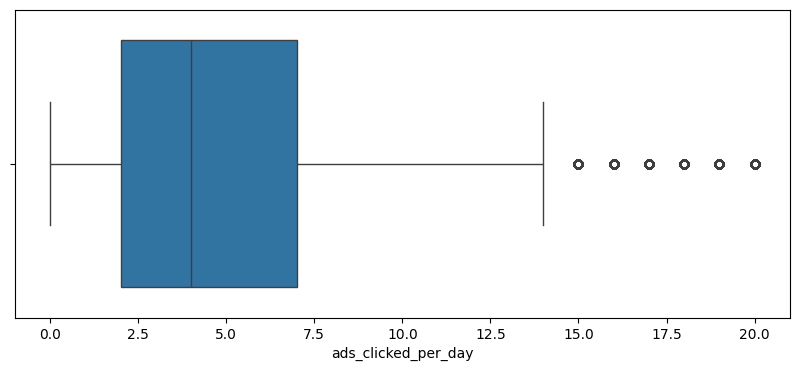

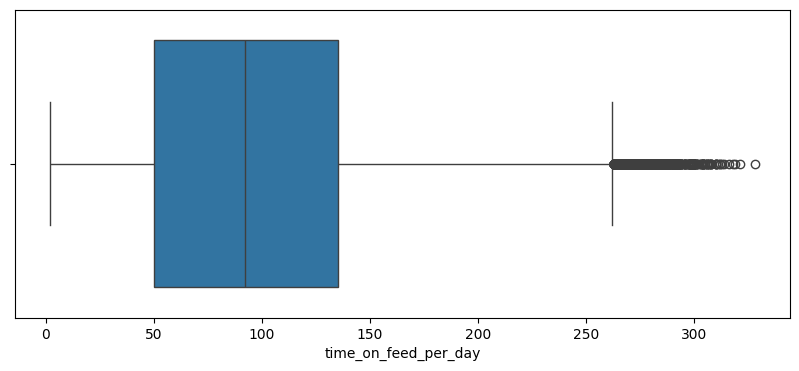

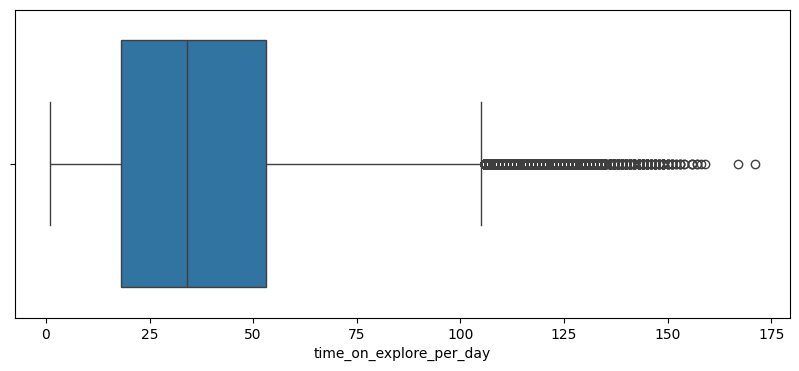

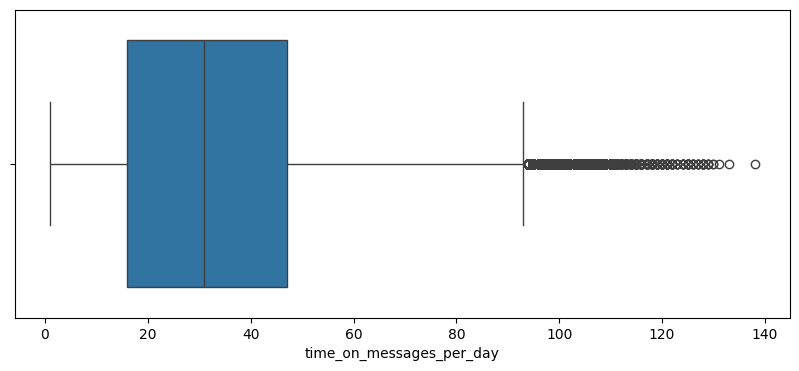

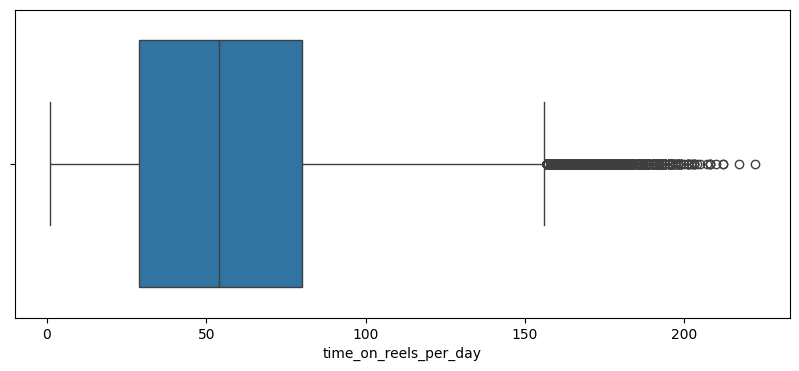

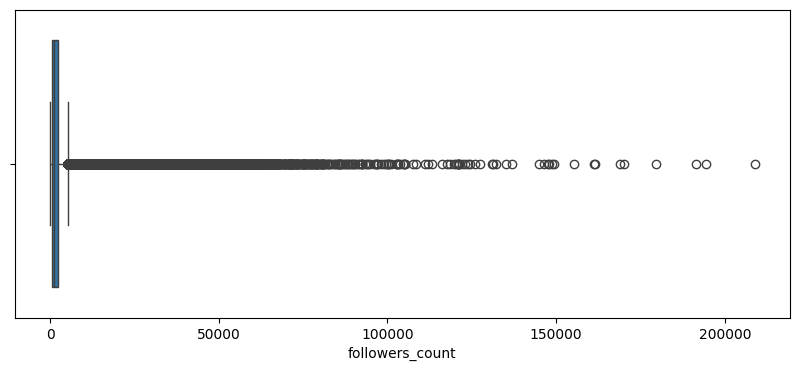

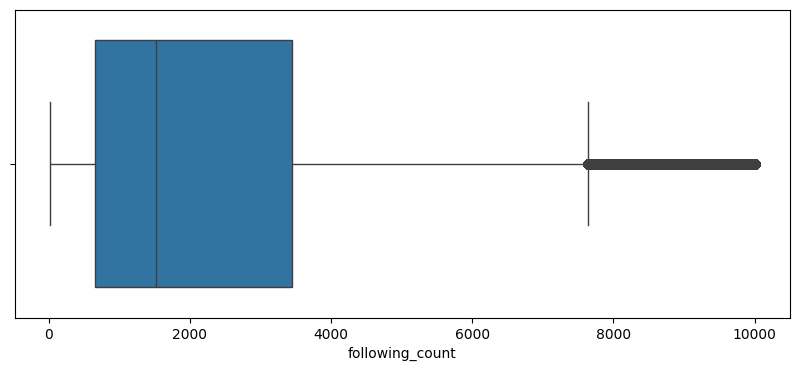

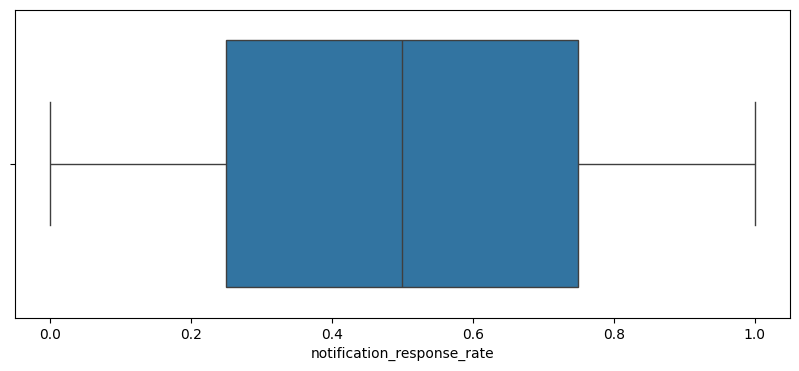

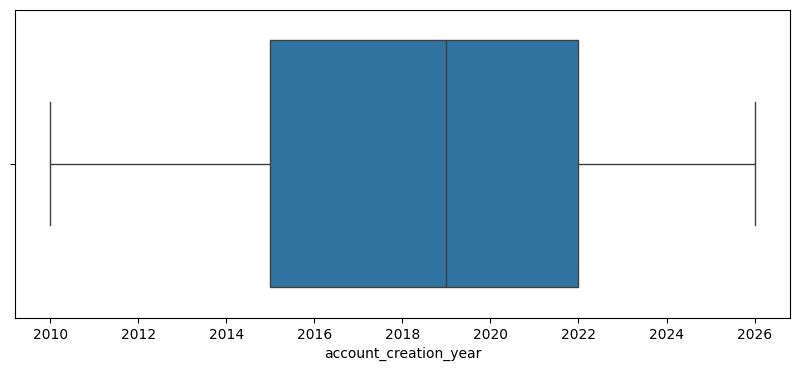

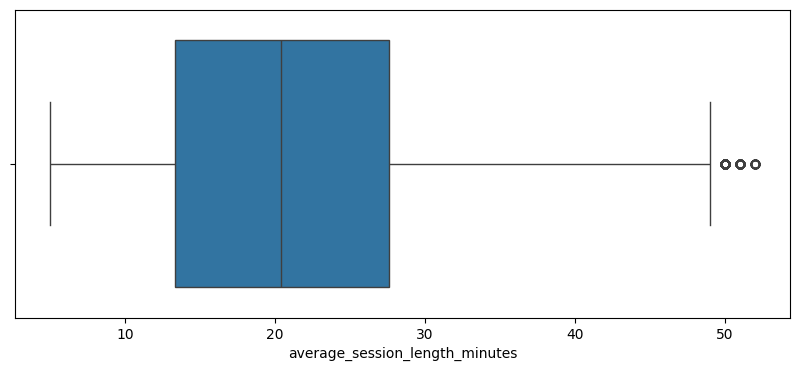

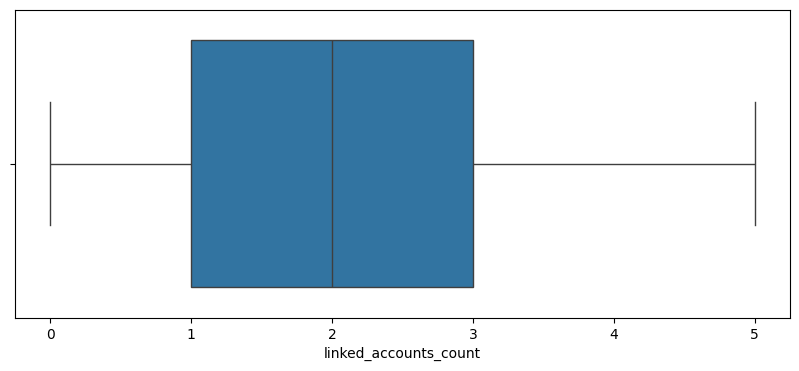

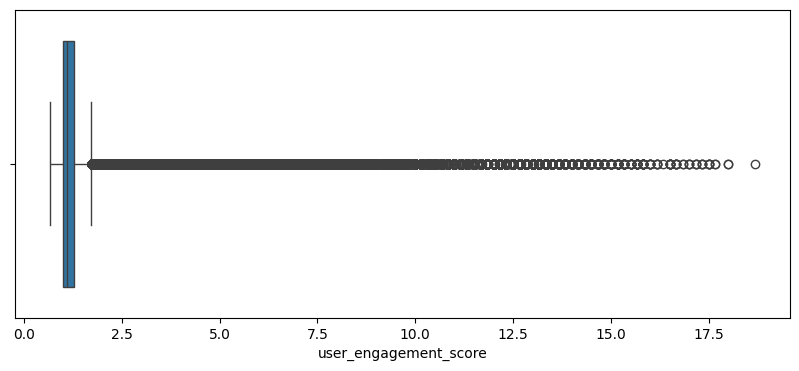

In [17]:
for col in df.select_dtypes('number').columns:
    fig, axes = plt.subplots(nrows=1,ncols=1)
    fig.set_size_inches(10, 4)
    sns.boxplot(data=df.select_dtypes('number'),x=col,orient="o",ax=axes)
    plt.show()

In [18]:
numerical_data = df[[
    'exercise_hours_per_week', 'sleep_hours_per_night','body_mass_index',
       'daily_steps_count', 'weekly_work_hours', 'hobbies_count',
       'social_events_per_month', 'books_read_per_year',
       'volunteer_hours_per_month', 'travel_frequency_per_year',
       ]]
for column in numerical_data.columns:
    Q1=numerical_data[column].quantile(0.25)
    Q3=numerical_data[column].quantile(0.75)
    IQR = Q3-Q1

    Lower_bound = Q1 - 1.5*IQR
    Upper_bound = Q3 + 1.5*IQR

    outliers = ((numerical_data[column]>Upper_bound)|(numerical_data[column]<Lower_bound)).sum()
    Total = numerical_data[column].shape[0]
    print(f'Total of outliers in {column} are   :   {outliers}--{round(100*(outliers)/Total,2)}%')
        
    if outliers > 0:
        df=df.loc[(df[column] <= Upper_bound) & (df[column] >= Lower_bound)]

Total of outliers in exercise_hours_per_week are   :   10387--0.67%
Total of outliers in sleep_hours_per_night are   :   14835--0.96%
Total of outliers in body_mass_index are   :   5071--0.33%
Total of outliers in daily_steps_count are   :   11066--0.71%
Total of outliers in weekly_work_hours are   :   149465--9.66%
Total of outliers in hobbies_count are   :   18403--1.19%
Total of outliers in social_events_per_month are   :   33207--2.15%
Total of outliers in books_read_per_year are   :   11711--0.76%
Total of outliers in volunteer_hours_per_month are   :   23567--1.52%
Total of outliers in travel_frequency_per_year are   :   18526--1.2%


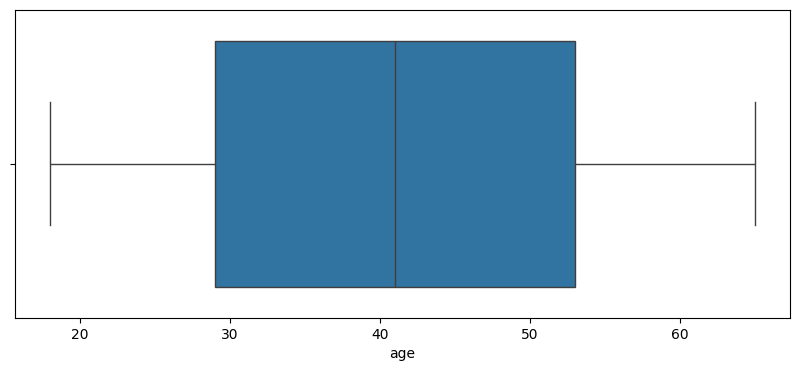

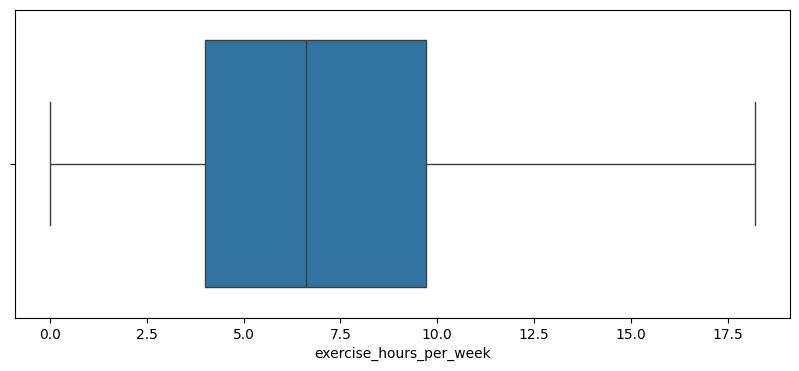

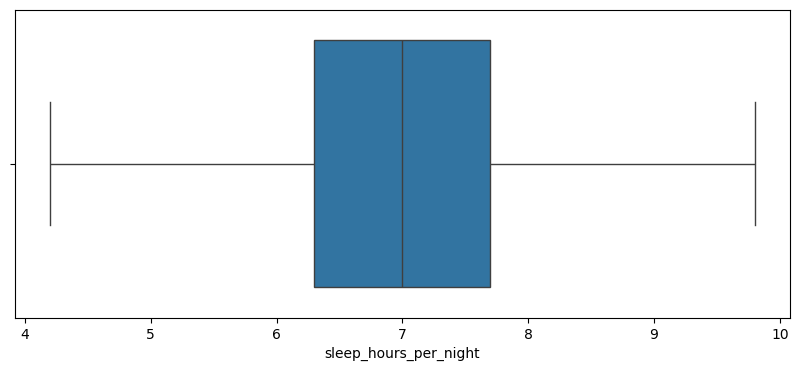

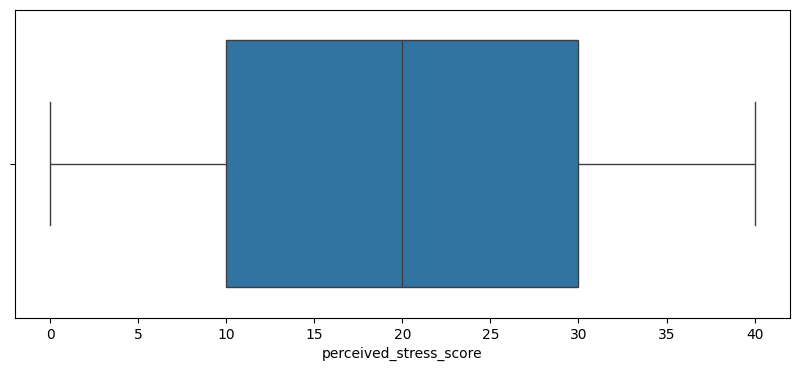

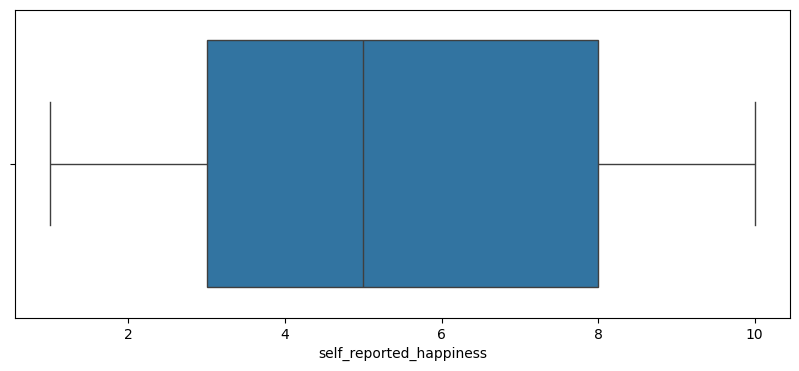

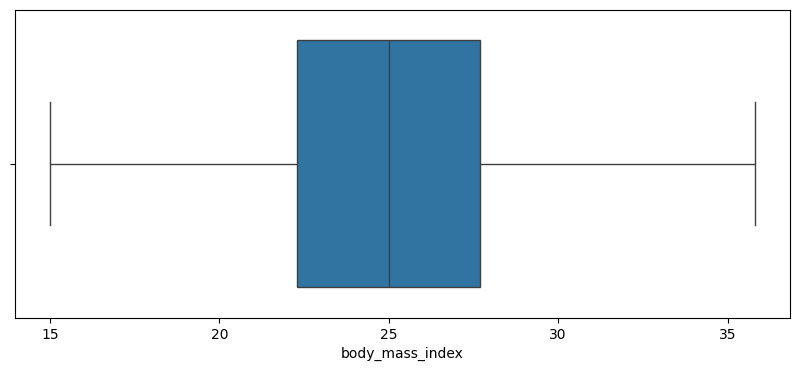

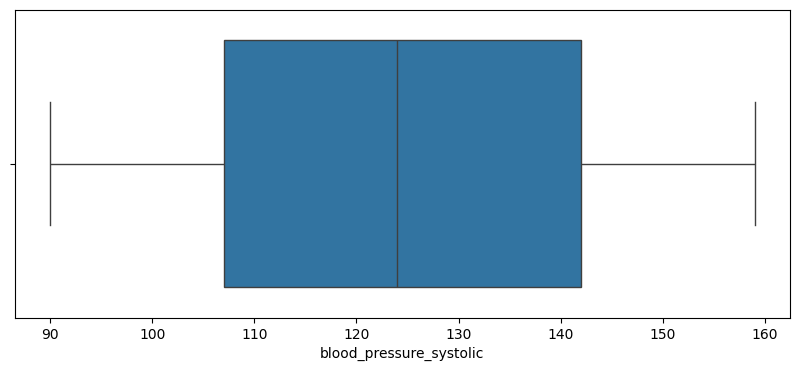

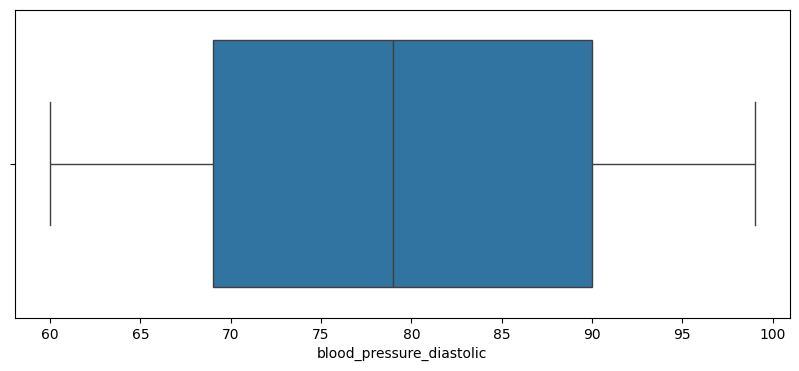

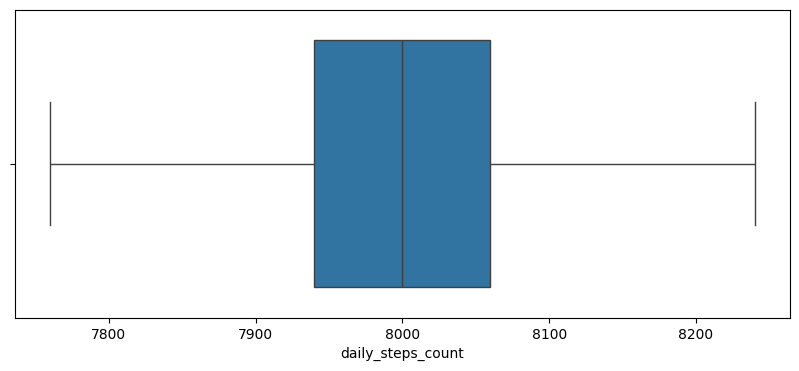

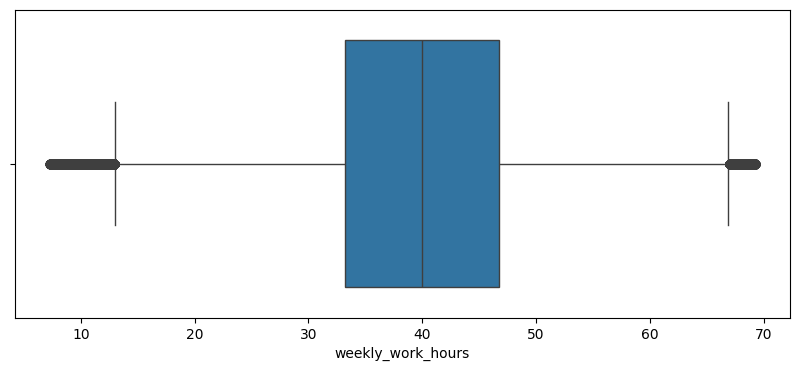

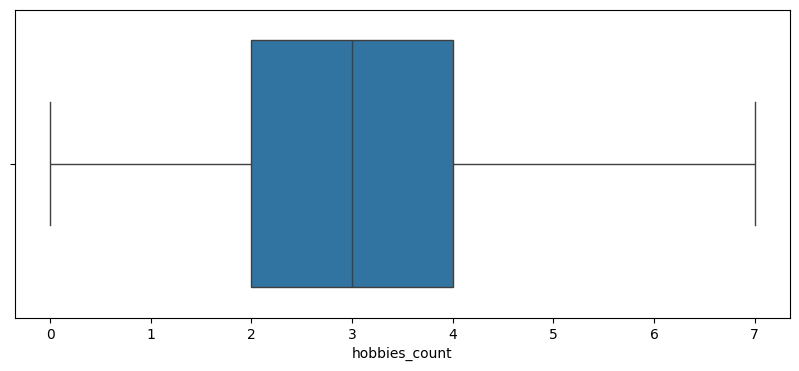

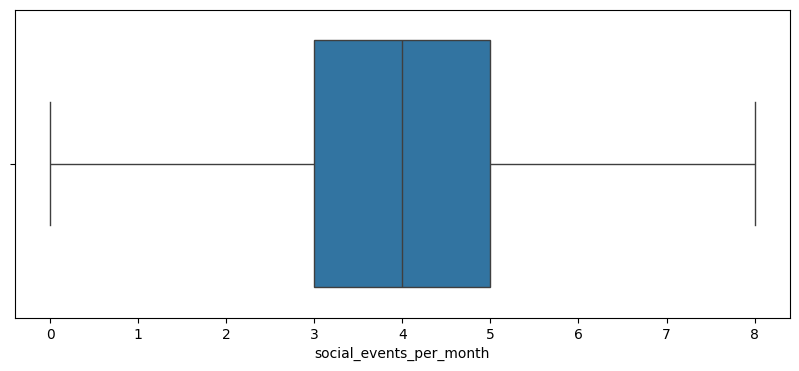

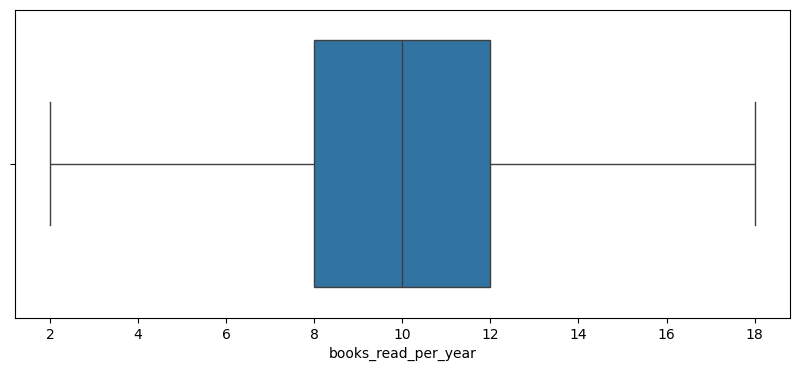

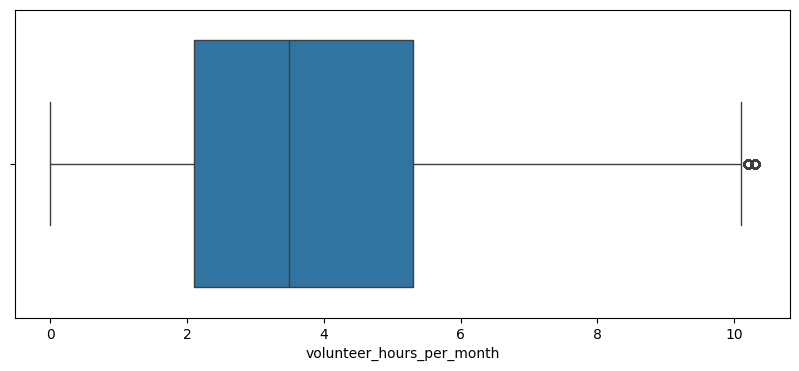

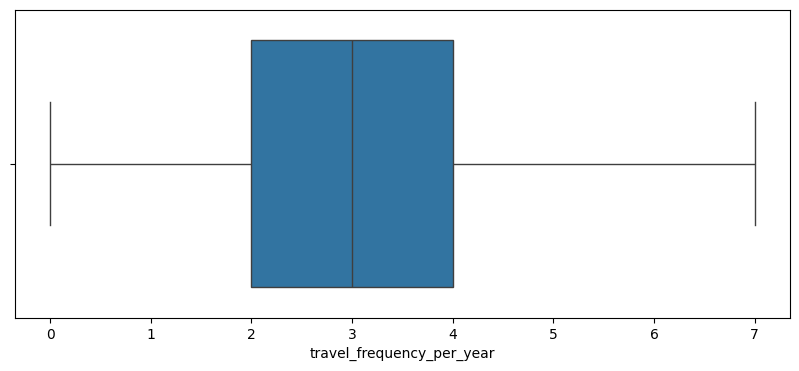

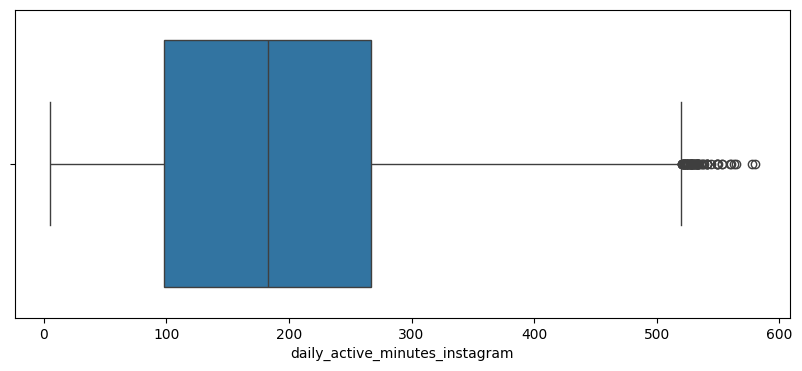

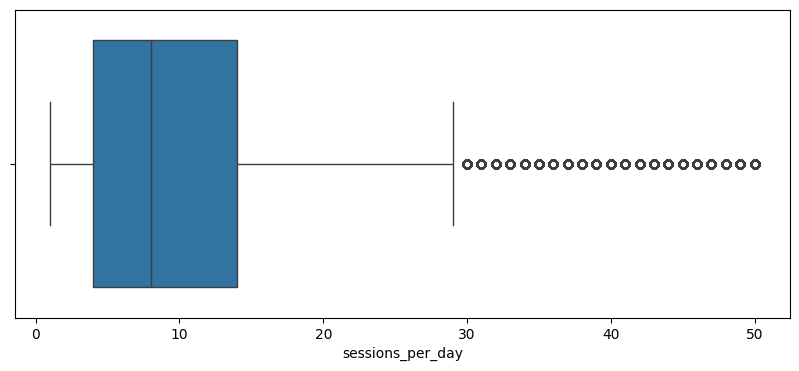

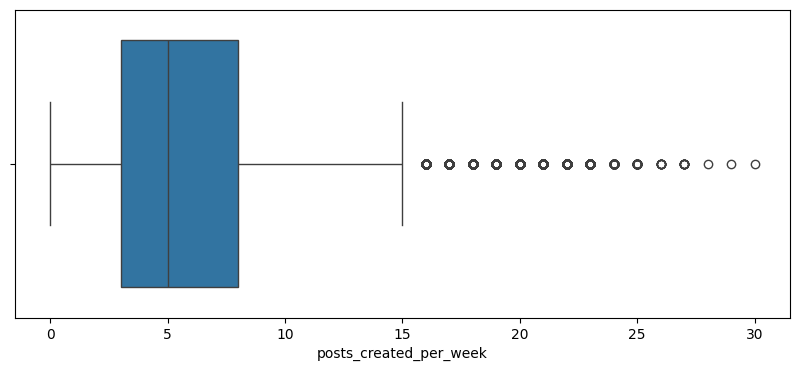

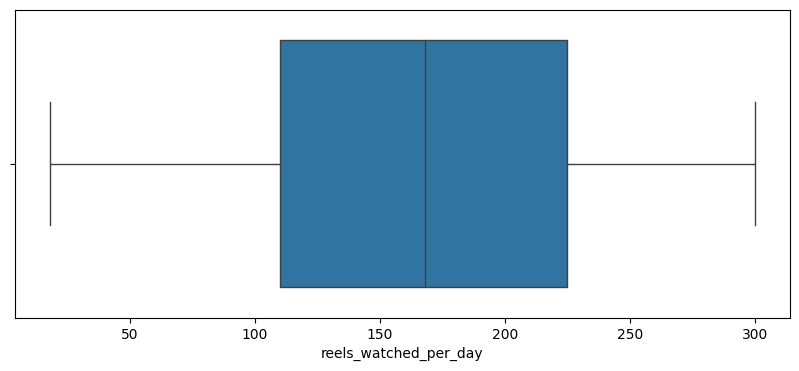

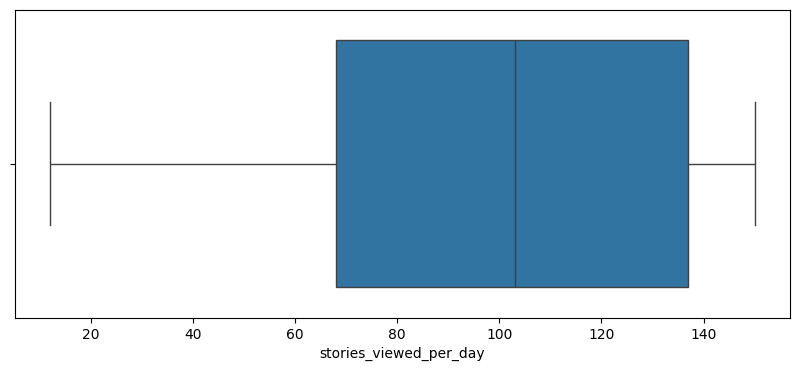

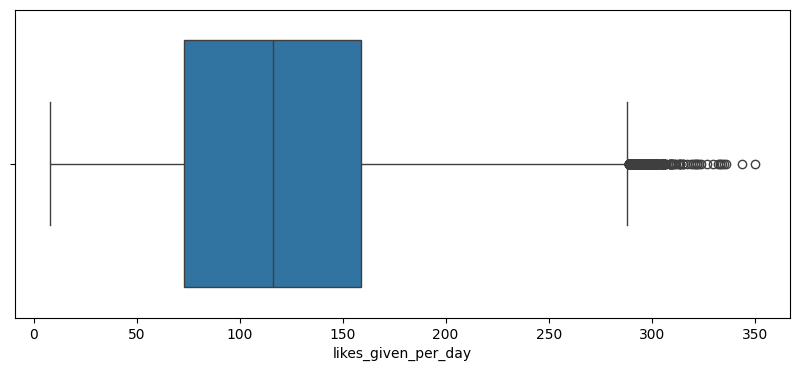

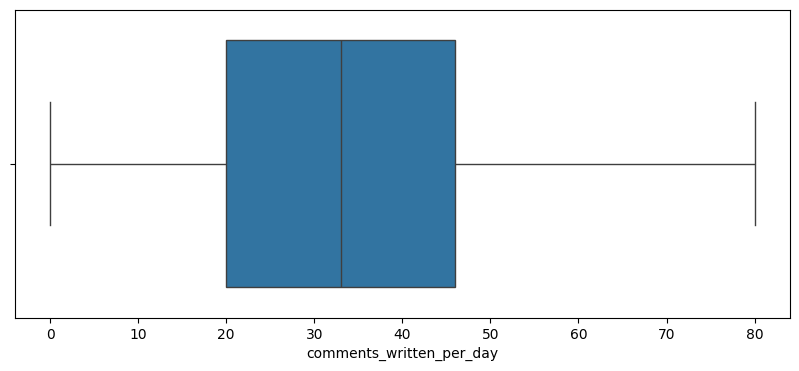

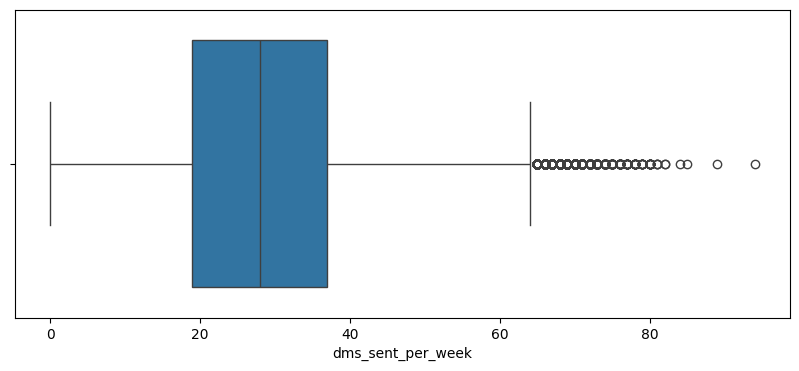

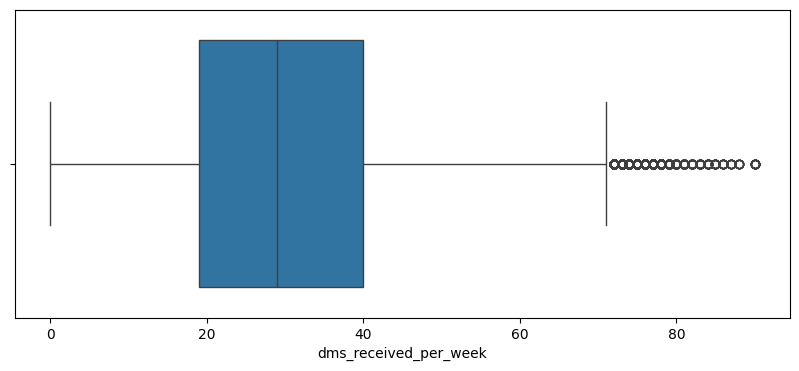

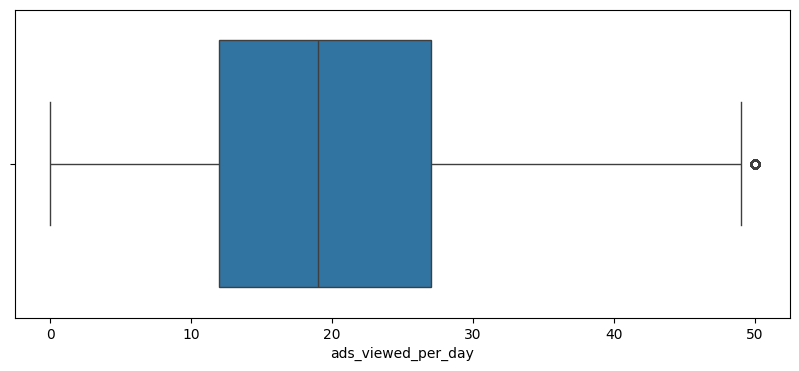

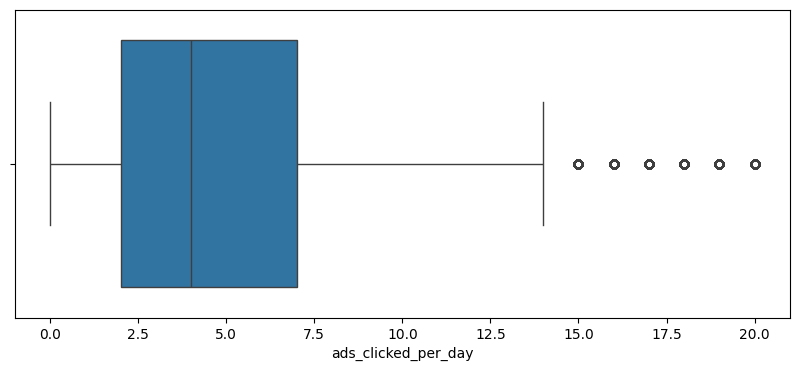

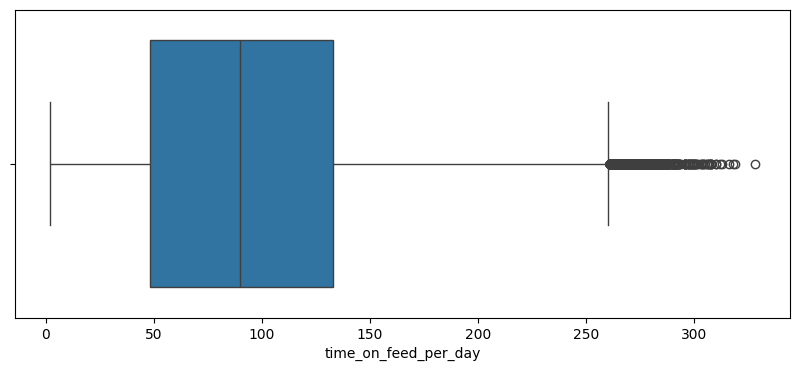

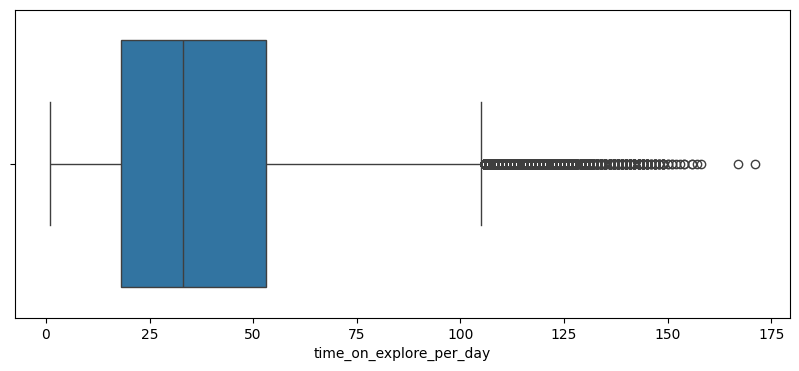

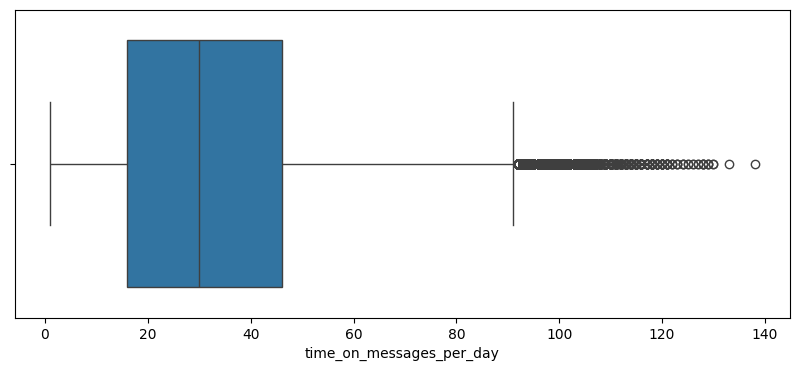

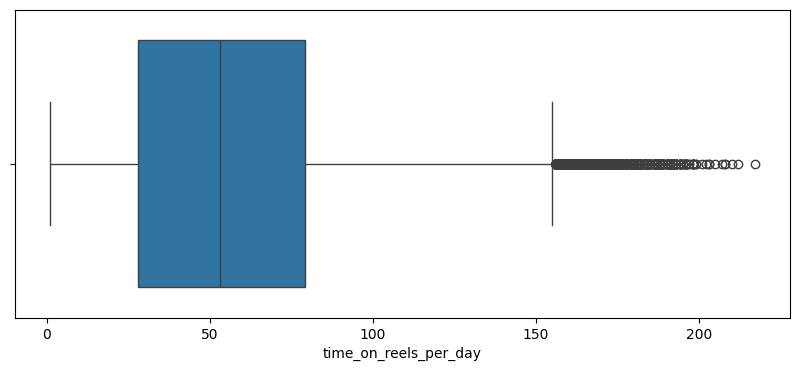

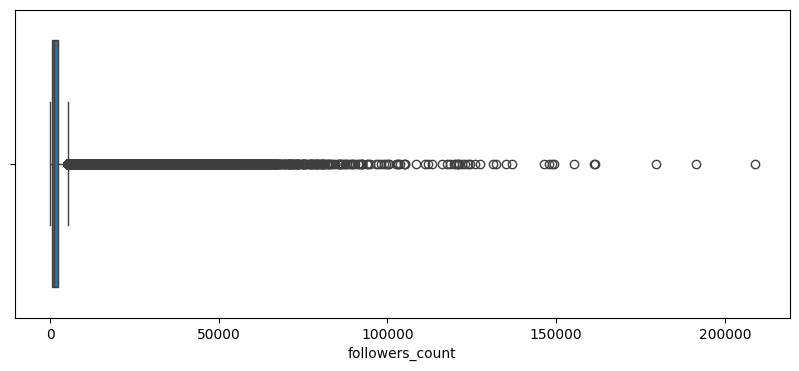

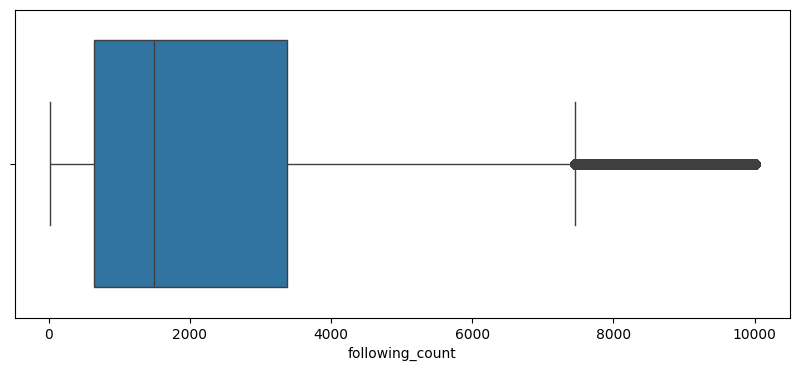

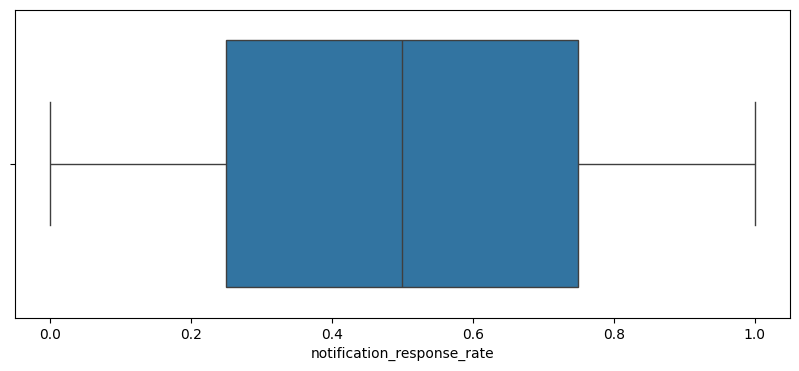

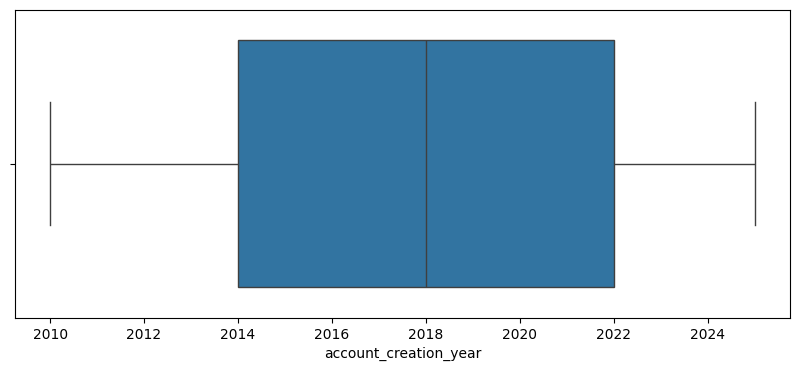

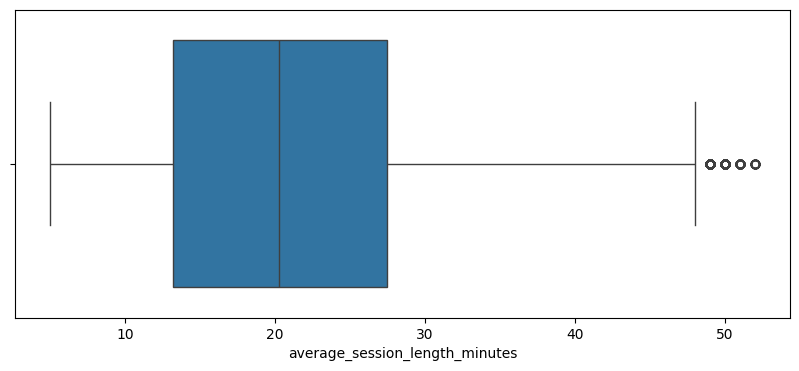

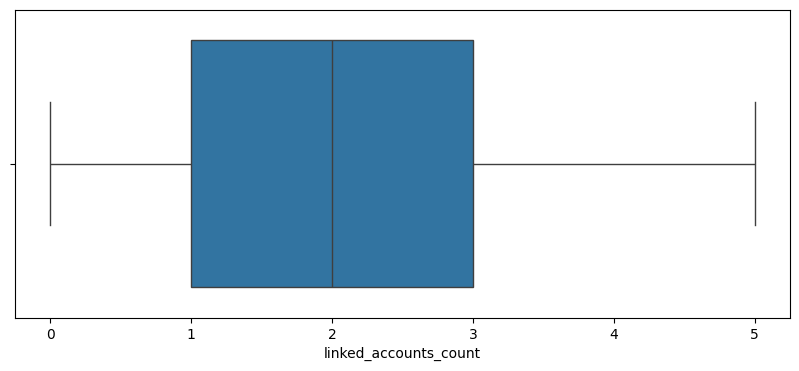

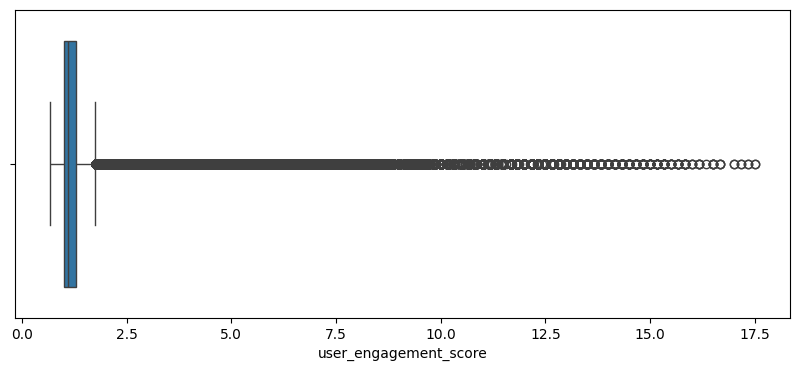

In [19]:
for col in df.select_dtypes('number').columns:
    fig, axes = plt.subplots(nrows=1,ncols=1)
    fig.set_size_inches(10, 4)
    sns.boxplot(data=df.select_dtypes('number'),x=col,orient="o",ax=axes)
    plt.show()

-----------------------------------------
### **Distribution of Variables**
--------------------------------------

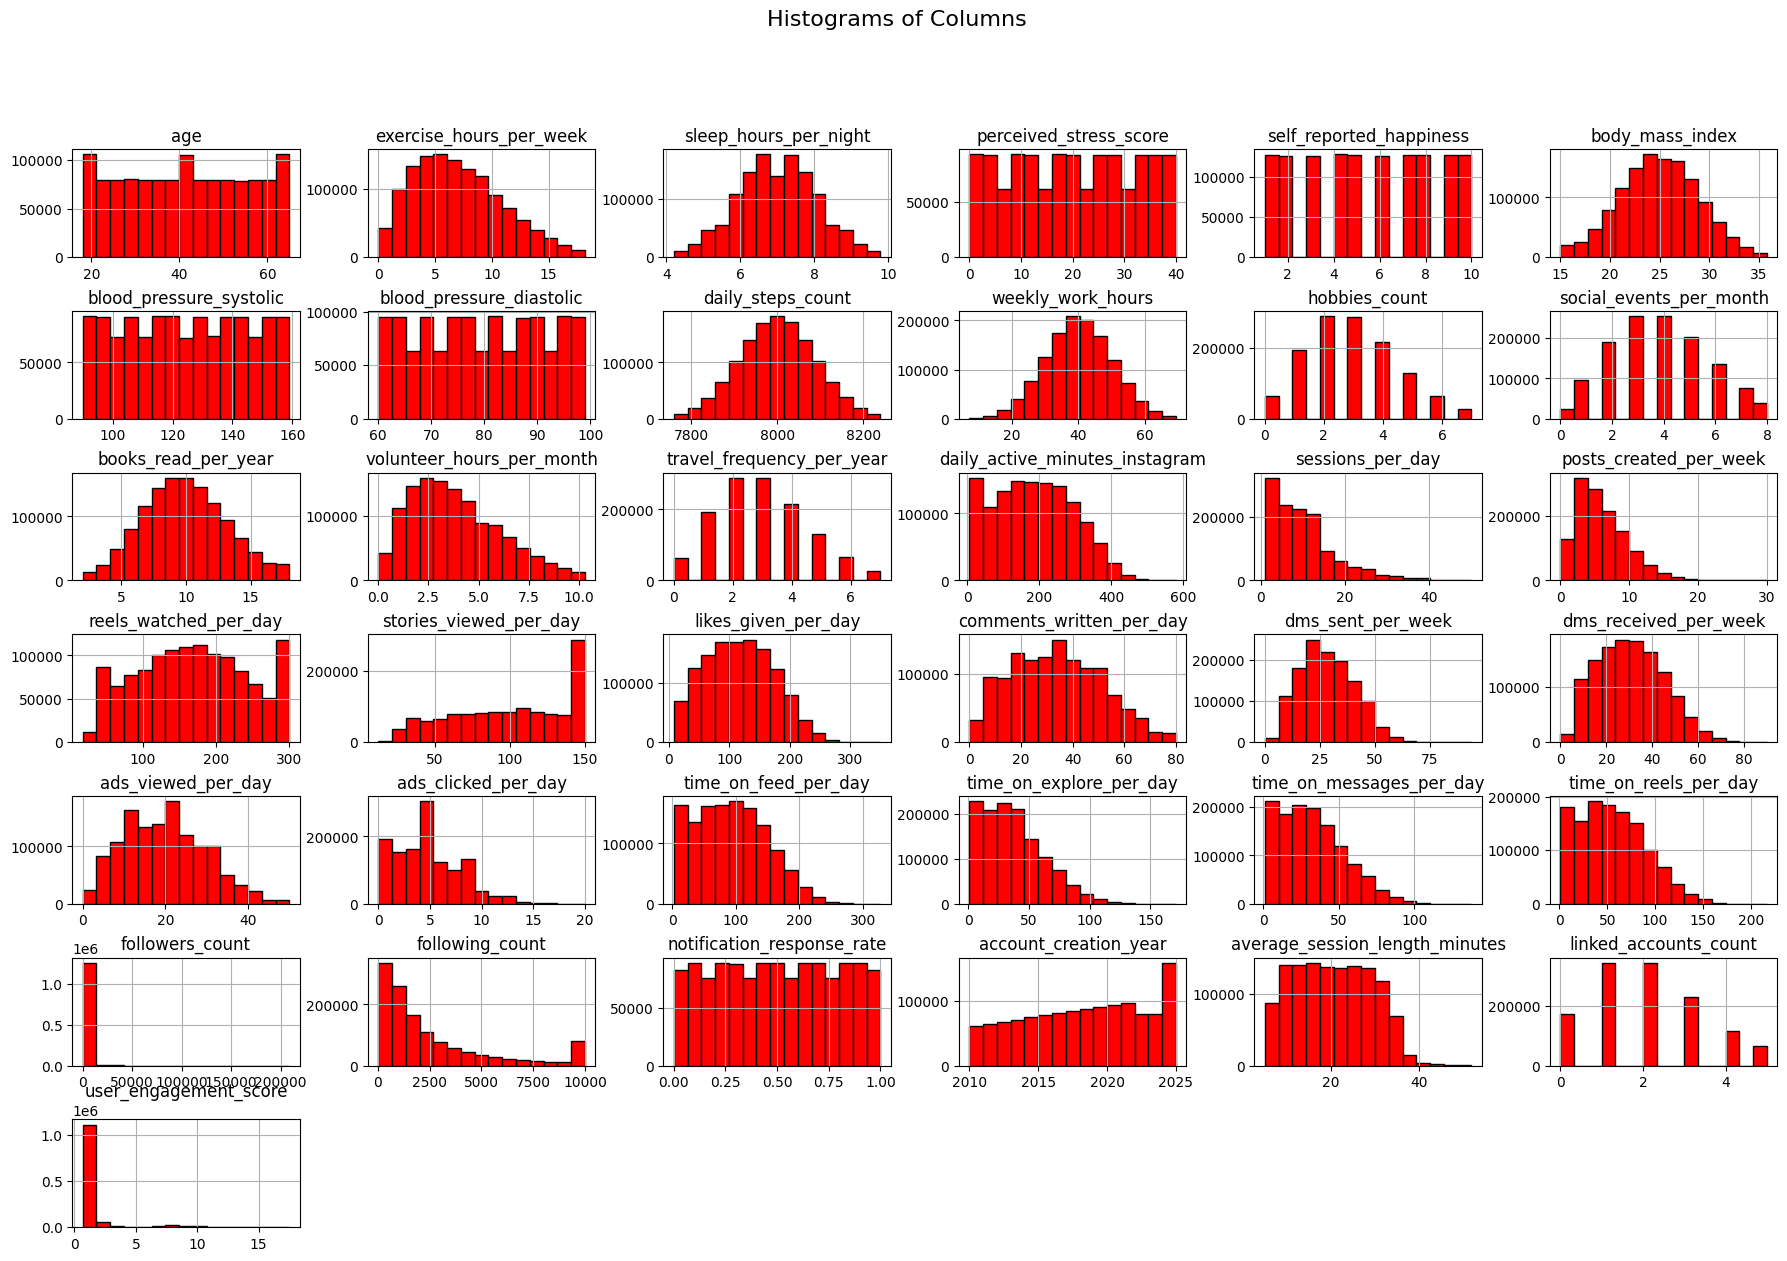

In [20]:
df.select_dtypes('number').hist(bins=15, figsize=(22, 14), color='red', edgecolor='black')

plt.suptitle('Histograms of Columns', fontsize=16)
plt.subplots_adjust(hspace=0.5)  
plt.show()

--------------------------------
### **Summary Statistical : value_counts()**
--------------------------------

In [21]:
def pie(data,col):
    data[col].value_counts().plot.pie(autopct='%0.2f%%')
    plt.xlabel(col)
    plt.show()

def countplot(data,col):
    plt.fig,ax= plt.subplots()
    plt.fig.set_size_inches(18,5)    
    sns.countplot(x=data[col], data=df)
    plt.xlabel(col)
    plt.xticks(rotation = 45)
    plt.show()

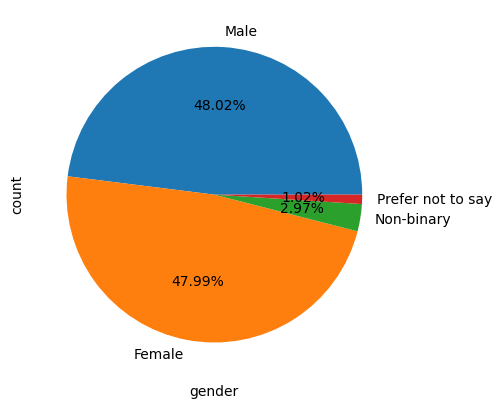

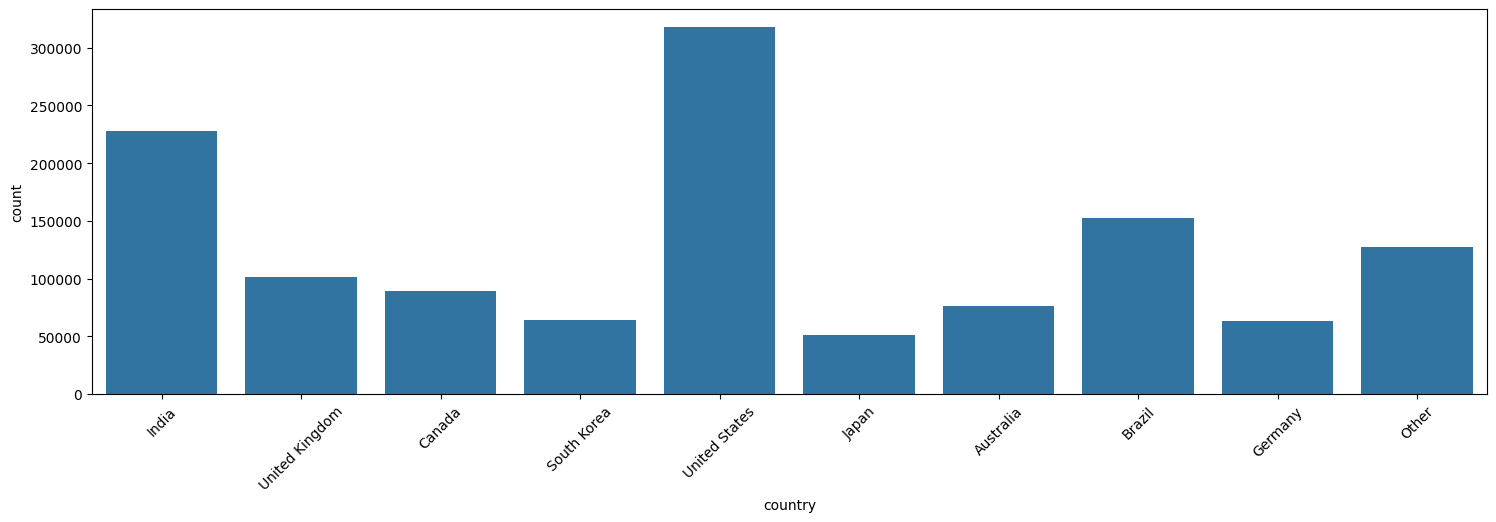

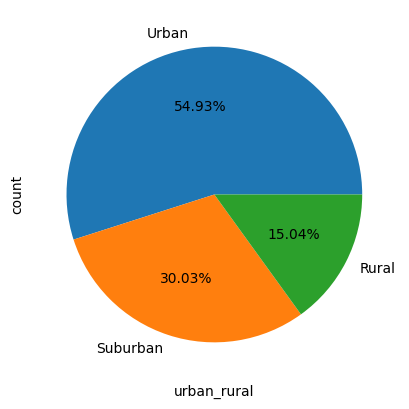

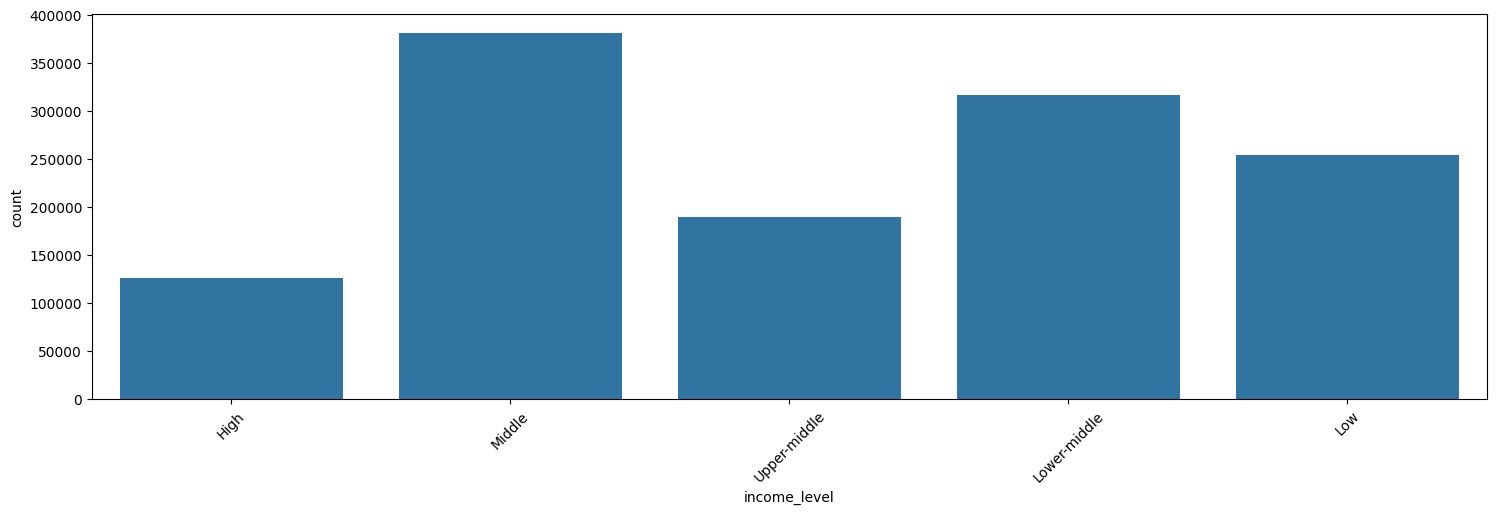

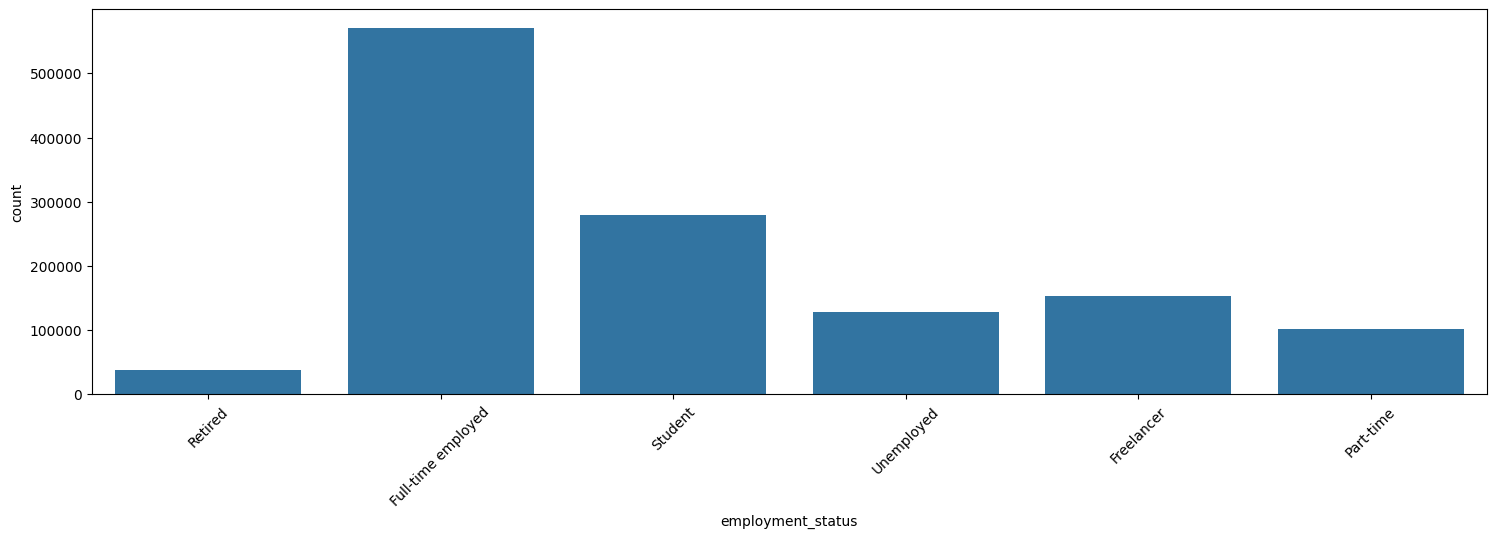

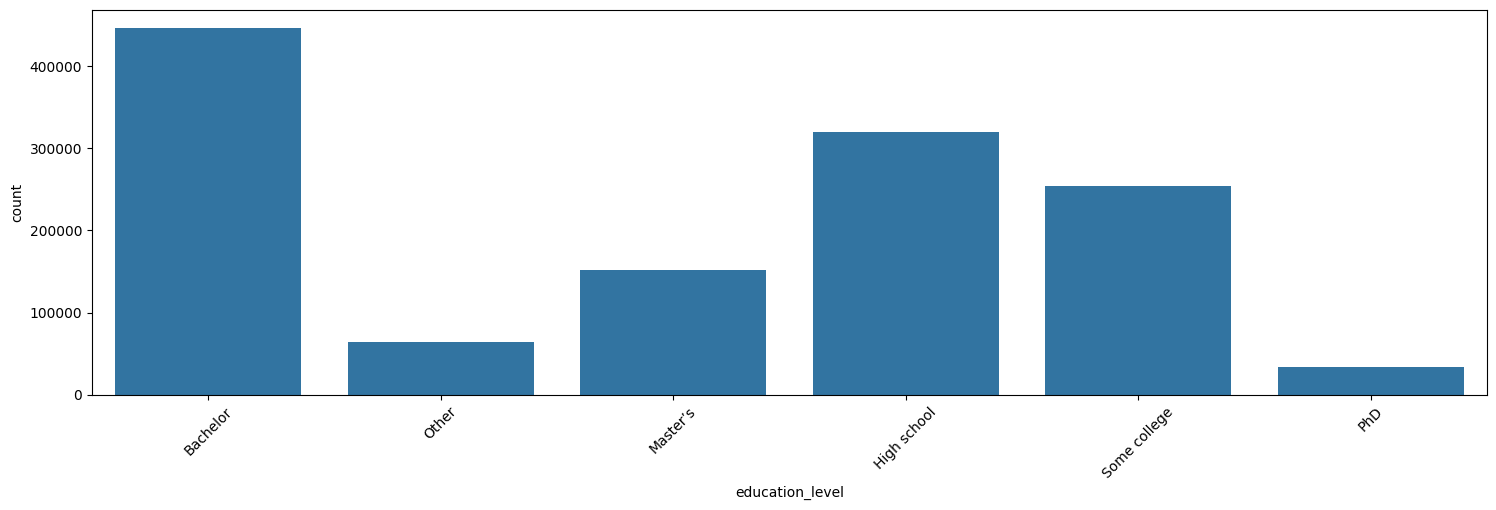

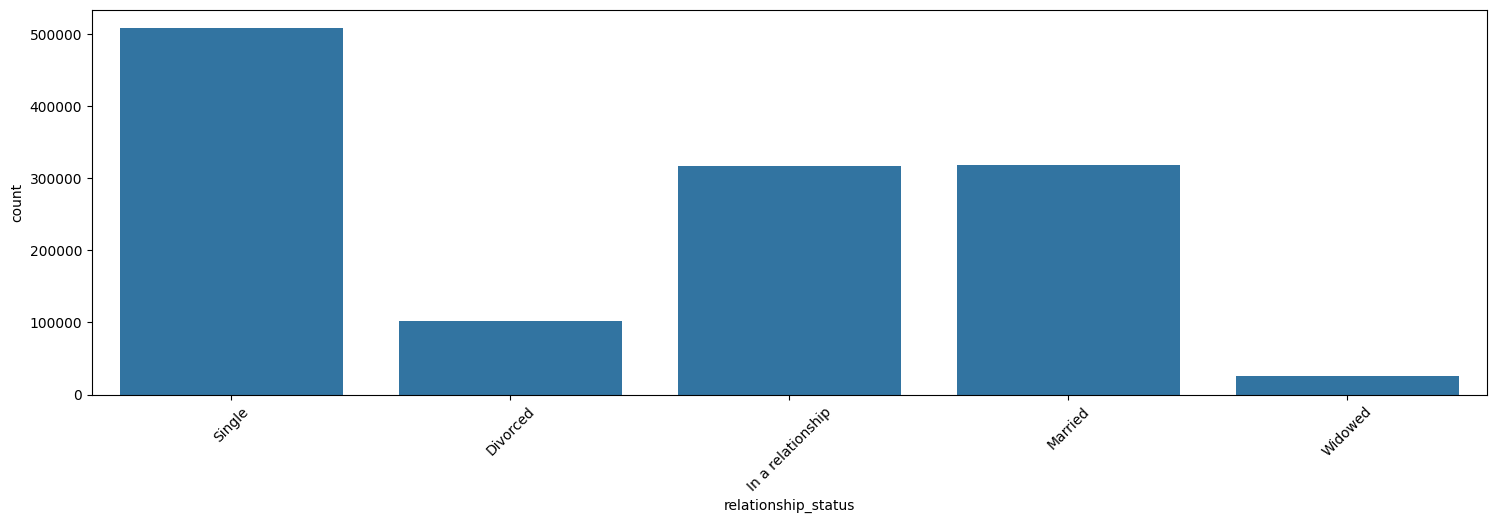

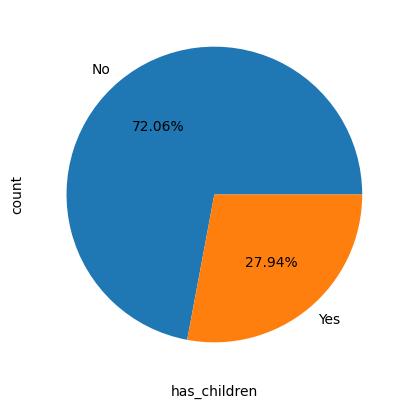

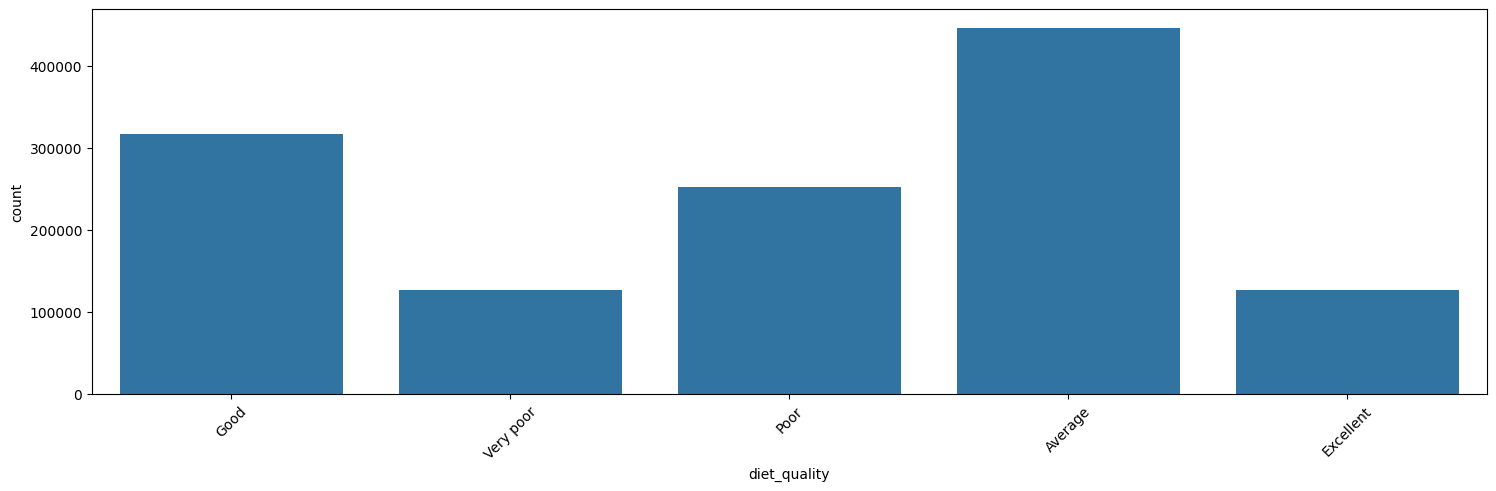

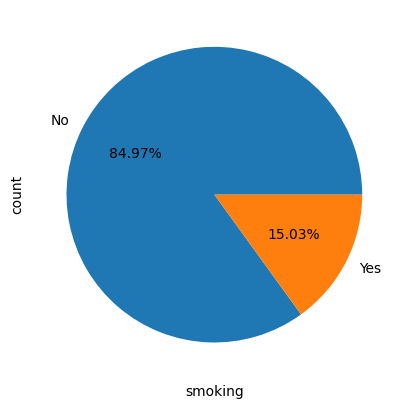

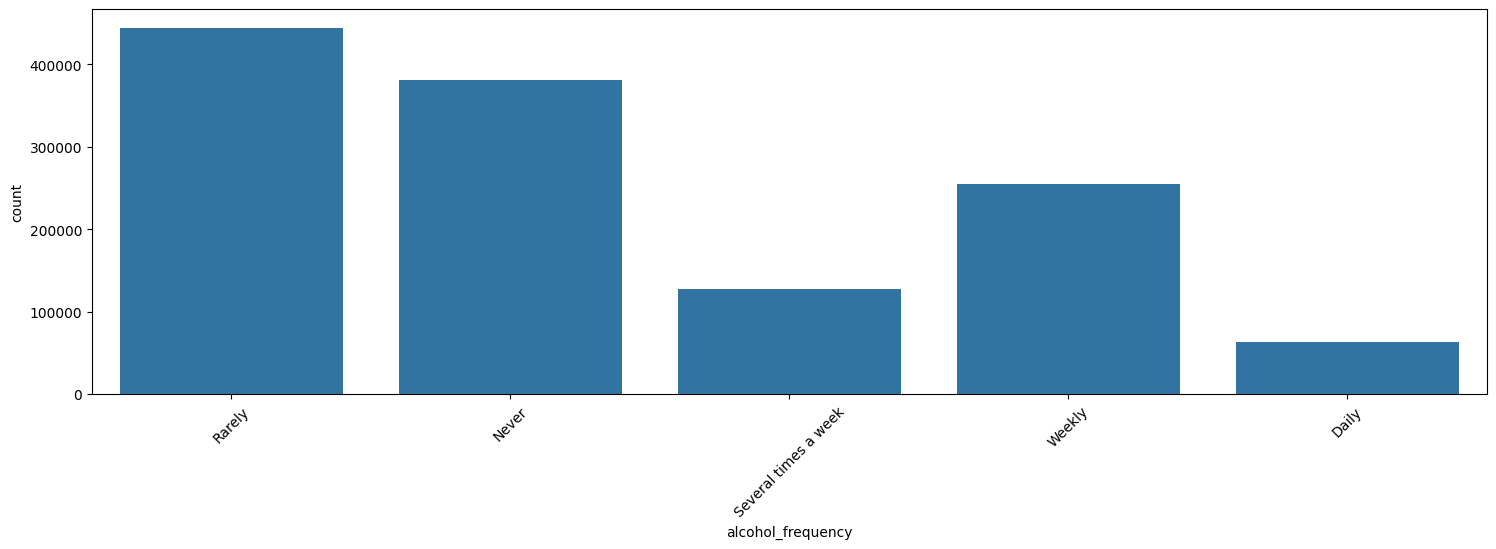

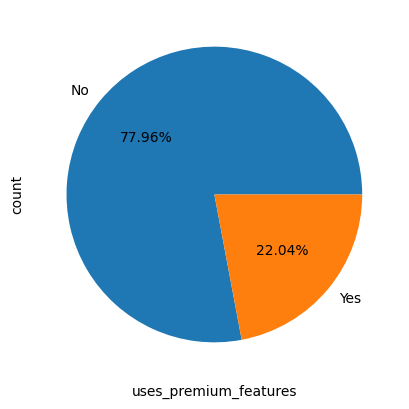

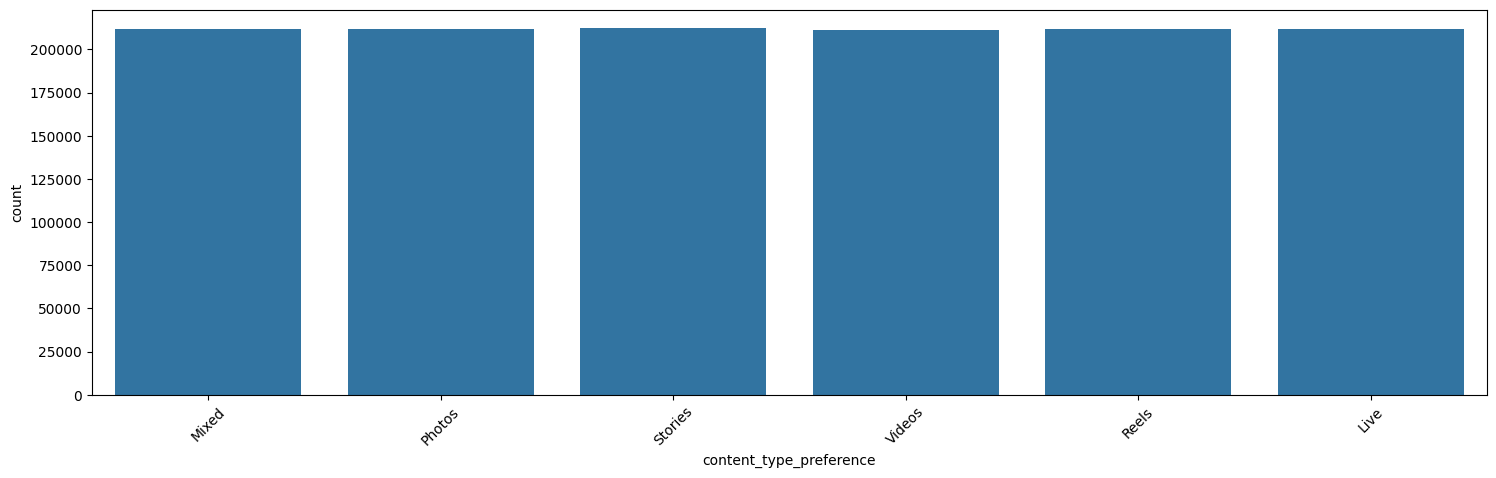

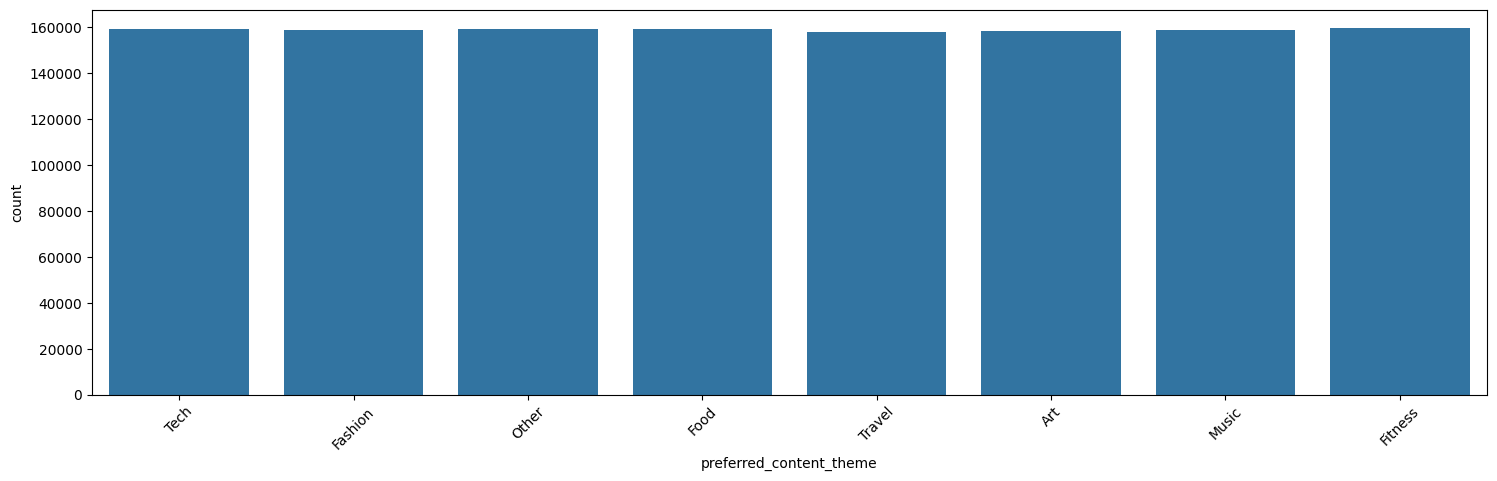

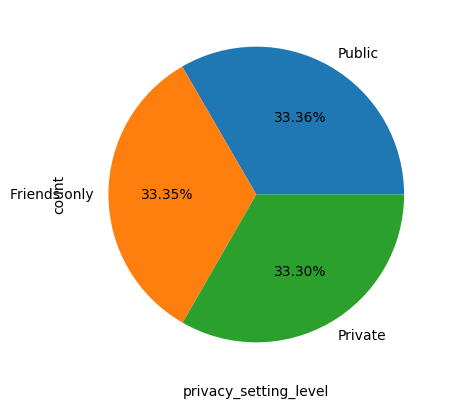

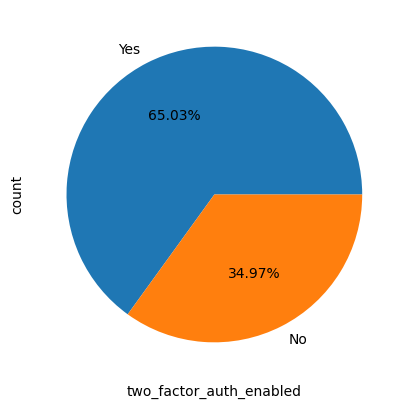

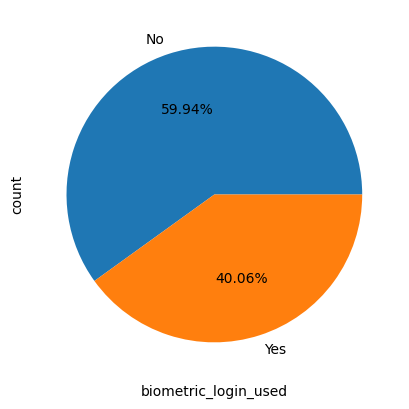

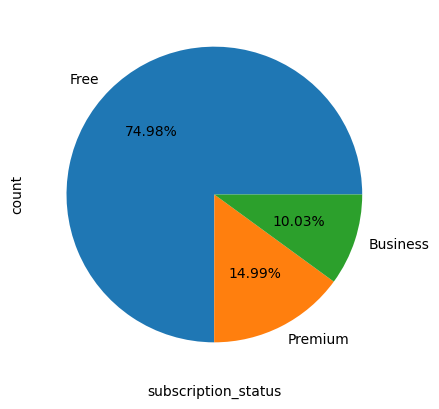

In [22]:
for col in df.select_dtypes('object').drop(['app_name','last_login_date'],axis=1).columns:
    if df.select_dtypes('object')[col].nunique() >=2 and df.select_dtypes('object')[col].nunique() <=4:
        pie(df.select_dtypes('object'),col)
    else :
        countplot(df.select_dtypes('object'),col)

-----------------------------
### **Checking Correlation between the features**
------------------------------

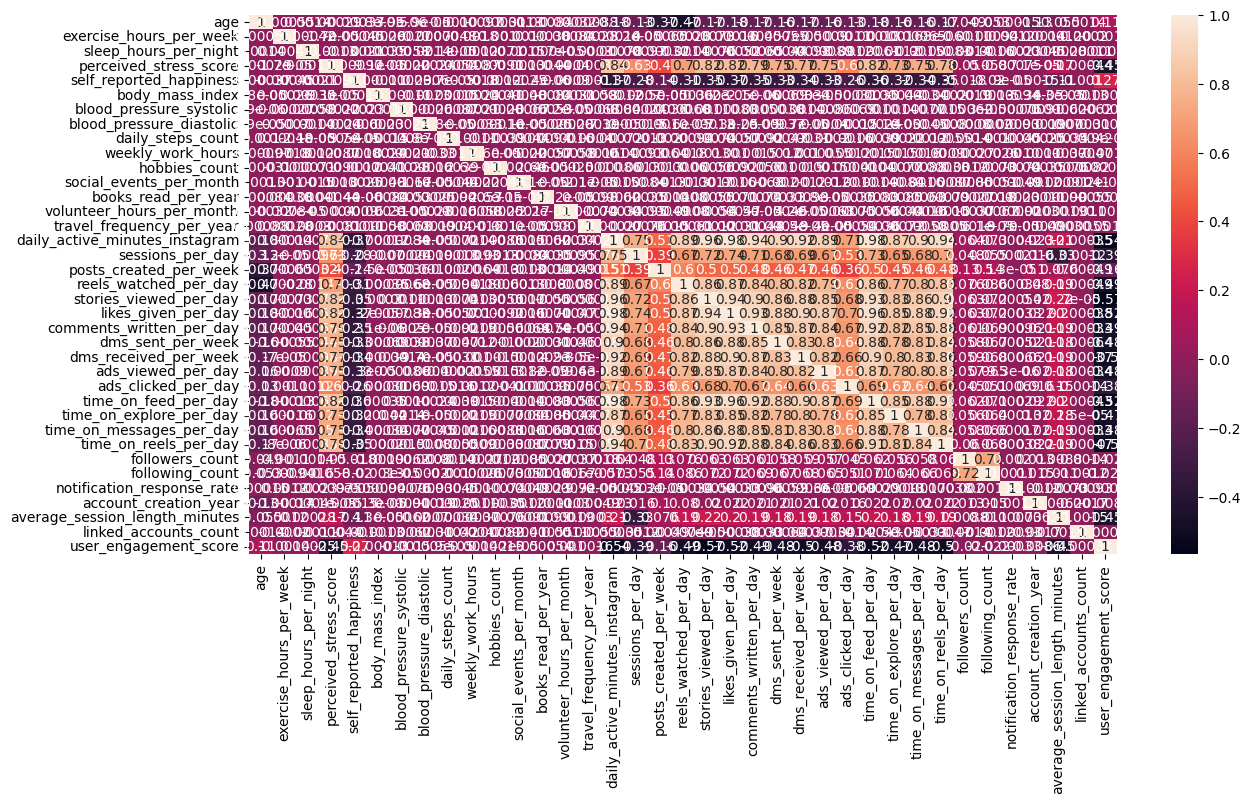

In [23]:
plt.figure(figsize=(14,	7))
sns.heatmap(df.select_dtypes('number').corr(), annot=True)
plt.show()

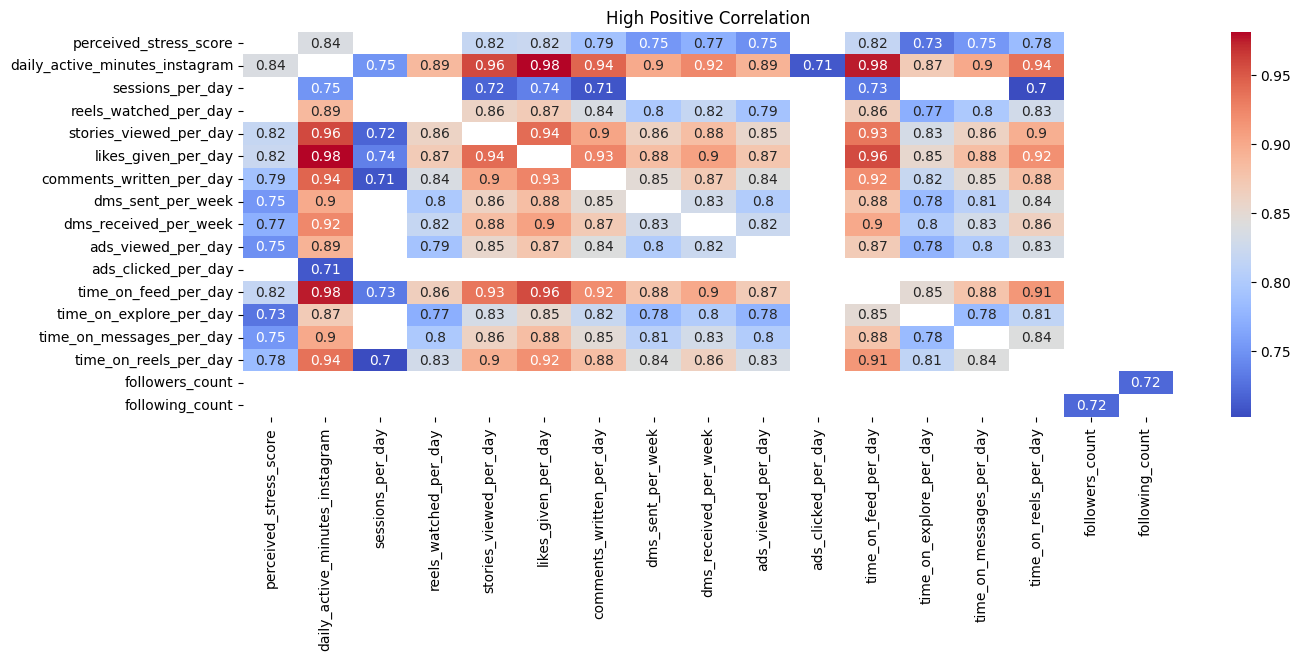

In [24]:
# function to extract high positive correlated columns
def get_high_corr(df, threshold):
     corr = df.select_dtypes('number').corr()
     high_corr = corr[(corr >= threshold) & (corr != 1.000)]
     high_corr = high_corr.dropna(how='all', axis=1).dropna(how='all', axis=0)
     return high_corr

# get high positive correlated columns
high_corr = get_high_corr(df, 0.7)

# plot high positive correlated columns
plt.figure(figsize=(15, 5))
plot = sns.heatmap(high_corr, annot=True, cmap='coolwarm')
plot.set_title('High Positive Correlation')
plt.show()

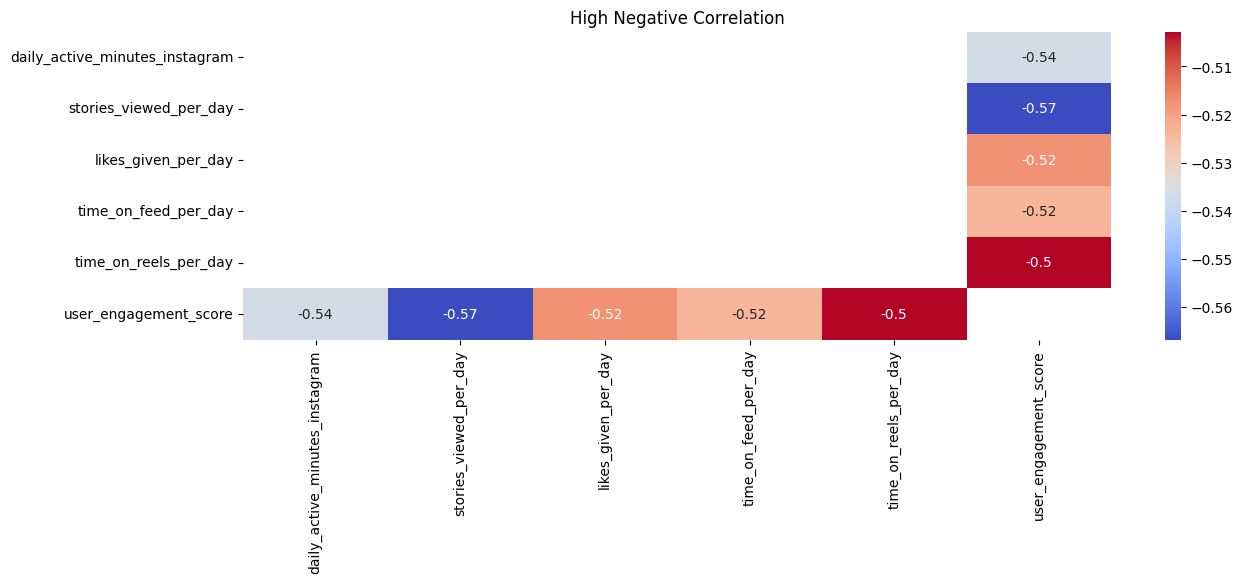

In [25]:
# function to extract high negative correlated columns
def get_high_corr(df, threshold):
     corr = df.select_dtypes('number').corr()
     high_corr = corr[(corr <= threshold) & (corr != 1.000)]
     high_corr = high_corr.dropna(how='all', axis=1).dropna(how='all', axis=0)
     return high_corr

# get high negative correlated columns
high_corr = get_high_corr(df, -0.5)

# plot high negative correlated columns
plt.figure(figsize=(14, 4))
plot = sns.heatmap(high_corr, annot=True, cmap='coolwarm')
plot.set_title('High Negative Correlation')
plt.show()

---------------------------------
---------------------------------
## **Feature Extraction**
---------------------------------

In [26]:
df['user_engagement_score'].describe()

count    1.270948e+06
mean     1.669270e+00
std      1.848281e+00
min      6.700000e-01
25%      1.000000e+00
50%      1.090000e+00
75%      1.300000e+00
max      1.750000e+01
Name: user_engagement_score, dtype: float64

In [27]:
def scoreSeg(a):
    if a <= 1:
        return 'Passive Users'
    elif a <= 1.10:
        return 'Casual Users'
    elif a <= 1.29:
        return 'Regular Users'
    else :
        return 'Power Users'

df['engagement_seg'] = df['user_engagement_score'].apply(lambda x: scoreSeg(x))

In [28]:
df['engagement_seg'].value_counts()

engagement_seg
Passive Users    338441
Casual Users     328700
Power Users      319468
Regular Users    284339
Name: count, dtype: int64

In [29]:
dtime = datetime.now()
# calcul age of cars
df['age_of_account']=dtime.year-df['account_creation_year']
df['age_of_account'].head()

0    11
1     8
2    15
3     7
4     9
Name: age_of_account, dtype: int64

In [30]:
# df.to_csv('filename.csv',index=False)

---------------------------
---------------------------
## **Selected features for classification model**
---------------------------

In [31]:
classif_df = df[[
    'age',
    'gender',
    'country',
    'urban_rural',
    'income_level',
    'employment_status',
    'education_level',
    'relationship_status',
    'has_children',
    'exercise_hours_per_week',
    'sleep_hours_per_night',
    'diet_quality',
    'smoking',
    'alcohol_frequency',
    'perceived_stress_score',
    'self_reported_happiness',
    'body_mass_index',
    'blood_pressure_systolic',
    'blood_pressure_diastolic',
    'daily_steps_count',
    'weekly_work_hours',
    'hobbies_count',
    'social_events_per_month',
    'books_read_per_year',
    'volunteer_hours_per_month',
    'travel_frequency_per_year',
    'notification_response_rate',
    'linked_accounts_count',
    'privacy_setting_level',
    'two_factor_auth_enabled',
    'biometric_login_used',
    'subscription_status',
    'uses_premium_features',
    'daily_active_minutes_instagram',
    'sessions_per_day',
    'posts_created_per_week',
    'reels_watched_per_day',
    'stories_viewed_per_day',
    'likes_given_per_day',
    'comments_written_per_day',
    'dms_sent_per_week',
    'dms_received_per_week',
    'ads_viewed_per_day',
    'ads_clicked_per_day',
    'time_on_feed_per_day',
    'time_on_explore_per_day',
    'time_on_messages_per_day',
    'time_on_reels_per_day',
    'average_session_length_minutes',
    'content_type_preference',
    'preferred_content_theme',
    'age_of_account',
    'engagement_seg'
]]

In [32]:
classif_df.head()

,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,exercise_hours_per_week,...,ads_clicked_per_day,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,average_session_length_minutes,content_type_preference,preferred_content_theme,age_of_account,engagement_seg
0,51,Female,India,Rural,High,Retired,Bachelor,Single,No,7.2,...,1,2,1,1,2,5.0,Mixed,Tech,11,Power Users
1,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,No,10.9,...,1,31,19,16,19,14.8,Photos,Fashion,8,Power Users
2,41,Female,Canada,Urban,Middle,Student,Bachelor,In a relationship,No,5.0,...,0,3,1,1,1,5.0,Mixed,Other,15,Power Users
3,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,No,10.6,...,3,108,64,52,64,25.9,Stories,Tech,7,Passive Users
4,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor,Single,No,7.7,...,5,78,55,22,55,13.1,Videos,Food,9,Casual Users


In [33]:
classif_df.select_dtypes('object').head()

,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,diet_quality,smoking,alcohol_frequency,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,subscription_status,uses_premium_features,content_type_preference,preferred_content_theme,engagement_seg
0,Female,India,Rural,High,Retired,Bachelor,Single,No,Good,No,Rarely,Private,Yes,No,Free,No,Mixed,Tech,Power Users
1,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,No,Very poor,No,Rarely,Public,No,No,Free,No,Photos,Fashion,Power Users
2,Female,Canada,Urban,Middle,Student,Bachelor,In a relationship,No,Good,No,Rarely,Public,Yes,Yes,Free,No,Mixed,Other,Power Users
3,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,No,Poor,Yes,Never,Private,No,No,Free,No,Stories,Tech,Passive Users
4,Male,India,Urban,Upper-middle,Full-time employed,Bachelor,Single,No,Average,No,Never,Public,Yes,No,Free,Yes,Videos,Food,Casual Users


In [34]:
classif_df.select_dtypes('number').head()

,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,weekly_work_hours,...,dms_sent_per_week,dms_received_per_week,ads_viewed_per_day,ads_clicked_per_day,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,average_session_length_minutes,age_of_account
0,51,7.2,7.7,3,8,20.8,148,86,8107,49.9,...,12,12,4,1,2,1,1,2,5.0,11
1,64,10.9,8.6,1,1,23.5,133,84,8059,15.6,...,18,10,11,1,31,19,16,19,14.8,8
2,41,5.0,6.7,4,10,28.6,135,88,7872,31.8,...,12,13,4,0,3,1,1,1,5.0,15
3,27,10.6,6.5,18,1,22.5,105,73,7801,43.4,...,31,32,33,3,108,64,52,64,25.9,7
4,55,7.7,6.8,19,1,28.1,146,90,8005,50.2,...,29,37,20,5,78,55,22,55,13.1,9


In [35]:
classif_df = classif_df[:1000200]

In [36]:
data_for_test = classif_df[1000000:]

In [37]:
data_for_test.to_excel('data_for_test.xlsx',index=False)

In [38]:
classif_df = classif_df[:1000000]

In [39]:
# dnn_df = classif_df.copy()

------------------------------------
### **Pipeline**
------------------------------------

In [40]:
d = {'Passive Users': 0, 'Casual Users': 1, 'Regular Users' : 2, 'Power Users' : 3}
classif_df['engagement_seg'] = classif_df['engagement_seg'].map(d)

In [41]:
classif_df['engagement_seg'].value_counts()

engagement_seg
0    266290
1    259013
3    251197
2    223500
Name: count, dtype: int64

In [42]:
classif_df.select_dtypes('object').columns

Index(['gender', 'country', 'urban_rural', 'income_level', 'employment_status',
       'education_level', 'relationship_status', 'has_children',
       'diet_quality', 'smoking', 'alcohol_frequency', 'privacy_setting_level',
       'two_factor_auth_enabled', 'biometric_login_used',
       'subscription_status', 'uses_premium_features',
       'content_type_preference', 'preferred_content_theme'],
      dtype='object')

In [43]:
ordered_cats = [
    ['Male','Female','Non-binary','Prefer not to say'],
    ['India', 'United Kingdom', 'Canada', 'South Korea', 'United States', 'Japan', 'Australia', 'Brazil', 'Other','Germany'],
    ['Rural', 'Urban', 'Suburban'],
    ['High', 'Upper-middle', 'Middle','Lower-middle', 'Low'],
    ['Retired', 'Full-time employed', 'Student', 'Unemployed', 'Freelancer', 'Not employed', 'Part-time'],
    ['Bachelor', 'Other', 'Master’s', 'High school', 'Some college','Secondary', 'PhD'],
    ['Single', 'Divorced', 'In a relationship', 'Married', 'Widowed'],
    ['No', 'Yes'],
    ['Very poor','Poor','Average','Good','Excellent'],
    ['No', 'Yes'],
    ['Never','Rarely','Several times a week','Weekly','Daily'],
    ['Private', 'Public', 'Friends only'],
    ['No', 'Yes'],
    ['No', 'Yes'],
    ['Free', 'Premium', 'Business'],
    ['No', 'Yes'],
    ['Stories','Mixed','Reels','Live','Videos','Photos'],
    ['Fitness','Other','Tech','Food','Fashion' ,'Music' ,'Art' ,'Travel']]

cats_cols = ['gender', 'country', 'urban_rural', 'income_level', 'employment_status',
             'education_level', 'relationship_status', 'has_children',
             'diet_quality', 'smoking', 'alcohol_frequency', 'privacy_setting_level',
             'two_factor_auth_enabled', 'biometric_login_used',
             'subscription_status', 'uses_premium_features','content_type_preference','preferred_content_theme']

ordinal_pipeline = Pipeline(steps=[("encoder", OrdinalEncoder(categories = ordered_cats, handle_unknown="use_encoded_value",unknown_value=-1))])

In [44]:
num_cols = ['age', 'exercise_hours_per_week', 'sleep_hours_per_night',
       'perceived_stress_score', 'self_reported_happiness', 'body_mass_index',
       'blood_pressure_systolic', 'blood_pressure_diastolic',
       'daily_steps_count', 'weekly_work_hours', 'hobbies_count',
       'social_events_per_month', 'books_read_per_year',
       'volunteer_hours_per_month', 'travel_frequency_per_year',
       'notification_response_rate', 'linked_accounts_count',
       'daily_active_minutes_instagram', 'sessions_per_day',
       'posts_created_per_week', 'reels_watched_per_day',
       'stories_viewed_per_day', 'likes_given_per_day',
       'comments_written_per_day', 'dms_sent_per_week',
       'dms_received_per_week', 'ads_viewed_per_day', 'ads_clicked_per_day',
       'time_on_feed_per_day', 'time_on_explore_per_day',
       'time_on_messages_per_day', 'time_on_reels_per_day',
       'average_session_length_minutes', 'age_of_account']

numerical_transformer = Pipeline(steps=[('scaler', StandardScaler())])

In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_cols),
        ("ord", ordinal_pipeline, cats_cols)])

lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('LGBM_model', LGBMClassifier(
                                objective='multiclass',
                                num_class=4,
                                n_estimators=300,
                                learning_rate=0.05,
                                random_state=42 ))])

cat_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('CatBoost_model', CatBoostClassifier(
                                        iterations=300,
                                        learning_rate=0.05,
                                        depth=6,
                                        loss_function='MultiClass',
                                        random_seed=42,
                                        verbose=0 ))])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf_model', RandomForestClassifier())])

In [46]:
x = classif_df.drop('engagement_seg',axis=1)
y = classif_df['engagement_seg']

x_train,x_val,y_train,y_val = train_test_split(x,y,train_size=0.80,random_state=1234)

print(f'shape of x_train : {x_train.shape}')
print(f'shape of x_val : {x_val.shape}')
print('-------------------------------')
print(f'shape of y_train : {y_train.shape}')
print(f'shape of y_val : {y_val.shape}')

shape of x_train : (800000, 52)
shape of x_val : (200000, 52)
-------------------------------
shape of y_train : (800000,)
shape of y_val : (200000,)


In [47]:
def multiclass(pl_model):
    print(pl_model)
    pl_model.fit(x_train,y_train)
    pred = pl_model.predict(x_val)
    print("Classification Report : \n", classification_report(y_val, pred))
    print("Confusion_matrix : \n",confusion_matrix(y_val, pred))

----------------------------------------------------------

In [48]:
multiclass(lgbm_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age',
                                                   'exercise_hours_per_week',
                                                   'sleep_hours_per_night',
                                                   'perceived_stress_score',
                                                   'self_reported_happiness',
                                                   'body_mass_index',
                                                   'blood_pressure_systolic',
                                                   'blood_pressure_diastolic',
                                                   'daily_steps_count',
                                                   'weekly_work_hours',
       

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification Report : 
               precision    recall  f1-score   support

           0       0.98      0.96      0.97     53157
           1       0.93      0.95      0.94     52135
           2       0.94      0.94      0.94     44646
           3       0.98      0.98      0.98     50062

    accuracy                           0.96    200000
   macro avg       0.96      0.96      0.96    200000
weighted avg       0.96      0.96      0.96    200000

Confusion_matrix : 
 [[50907  2191    36    23]
 [  951 49324  1791    69]
 [    2  1645 42186   813]
 [    0     1  1019 49042]]


### **The model demonstrates exceptional performance with a 96% global accuracy and balanced F1-scores across all four classes, indicating high reliability and no significant bias toward a specific category. While the classification report shows near-perfect metrics, the confusion matrix reveals that the majority of errors occur as minor leakage between Class 1 and Class 2, suggesting these two categories may share overlapping feature characteristics. With a substantial test set of 200,000 samples, the results are statistically robust.**

In [49]:
with open('lgbm_pipeline.pkl' , 'wb') as f :
   pickle.dump(lgbm_pipeline, f)

-----------------------------------

In [50]:
multiclass(cat_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age',
                                                   'exercise_hours_per_week',
                                                   'sleep_hours_per_night',
                                                   'perceived_stress_score',
                                                   'self_reported_happiness',
                                                   'body_mass_index',
                                                   'blood_pressure_systolic',
                                                   'blood_pressure_diastolic',
                                                   'daily_steps_count',
                                                   'weekly_work_hours',
       

### **CatBoost model is performing solidly with a 91% overall accuracy, though it’s trailing slightly behind your previous LightGBM results. While Class 0 and Class 3 remain very strong with F1-scores of 0.94 and 0.95, the model struggles more with the middle categories; Class 1 and Class 2 show a noticeable dip in precision and recall (dropping to 0.86–0.89). The confusion matrix highlights that the most significant errors are "adjacent" misclassifications—specifically, Class 1 is being mistaken for Class 0 or Class 2 nearly 8,000 times total—suggesting that CatBoost might be finding it harder to draw clear decision boundaries between these closely related categories.**

In [51]:
with open('cat_pipeline.pkl' , 'wb') as f :
   pickle.dump(cat_pipeline, f)

----------------------------------------------

In [52]:
multiclass(rf_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age',
                                                   'exercise_hours_per_week',
                                                   'sleep_hours_per_night',
                                                   'perceived_stress_score',
                                                   'self_reported_happiness',
                                                   'body_mass_index',
                                                   'blood_pressure_systolic',
                                                   'blood_pressure_diastolic',
                                                   'daily_steps_count',
                                                   'weekly_work_hours',
       

### **The Random Forest model achieves a respectable 85% global accuracy, but it clearly struggles with decision boundaries compared to the boosting models, particularly in the middle categories where F1-scores drop significantly to 0.78 and 0.79. The confusion matrix reveals much heavier "bleeding" between adjacent classes, with over 11,000 misclassifications between Class 1 and its neighbors, indicating that the default forest structure is less efficient at capturing the subtle nonlinear patterns that LightGBM and CatBoost handled more precisely.**

In [53]:
with open('rf_pipeline.pkl' , 'wb') as f :
   pickle.dump(rf_pipeline, f)

--------------------------------
### **Classification model using DNN**
--------------------------------

In [54]:
ordinal_encoder = OrdinalEncoder(categories=ordered_cats)
x[cats_cols] = ordinal_encoder.fit_transform(x[cats_cols])

In [55]:
with open('ordinal_encoder.pkl','wb') as f:
    pickle.dump(ordinal_encoder, f)

In [56]:
scaler = StandardScaler()
x[num_cols] = scaler.fit_transform(x[num_cols])

In [57]:
with open('sclaer.pkl','wb') as f:
    pickle.dump(scaler, f)

In [58]:
x_train,x_val,y_train,y_val = train_test_split(x,y,train_size=0.80,random_state=1234)

print(f'shape of x_train : {x_train.shape}')
print(f'shape of x_val : {x_val.shape}')
print('-------------------------------')
print(f'shape of y_train : {y_train.shape}')
print(f'shape of y_val : {y_val.shape}')

shape of x_train : (800000, 52)
shape of x_val : (200000, 52)
-------------------------------
shape of y_train : (800000,)
shape of y_val : (200000,)


In [ ]:
num_classes = len(set(y))

model = models.Sequential([
    layers.Dense(256, input_shape=(52,)),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    #layers.Dropout(0.3),
    
    layers.Dense(128),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    
    layers.Dense(64),
    layers.LeakyReLU(alpha=0.1),
    
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
) 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
lr_scheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [87]:
history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=2024, 
    validation_data=(x_val, y_val),
    callbacks=[lr_scheduler, early_stopping])

Epoch 1/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.6847 - loss: 0.7169 - val_accuracy: 0.8379 - val_loss: 0.5168 - learning_rate: 0.0010
Epoch 2/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9475 - loss: 0.1210 - val_accuracy: 0.9616 - val_loss: 0.0861 - learning_rate: 0.0010
Epoch 3/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9592 - loss: 0.0940 - val_accuracy: 0.9658 - val_loss: 0.0794 - learning_rate: 0.0010
Epoch 4/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9650 - loss: 0.0812 - val_accuracy: 0.9761 - val_loss: 0.0564 - learning_rate: 0.0010
Epoch 5/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9671 - loss: 0.0771 - val_accuracy: 0.9729 - val_loss: 0.0607 - learning_rate: 0.0010
Epoch 6/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9680 - loss: 0.0747 - val_accuracy: 0.9711 - val_loss: 0.0642 - learning_rate: 0.0010
Epoch 7/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9697 - l

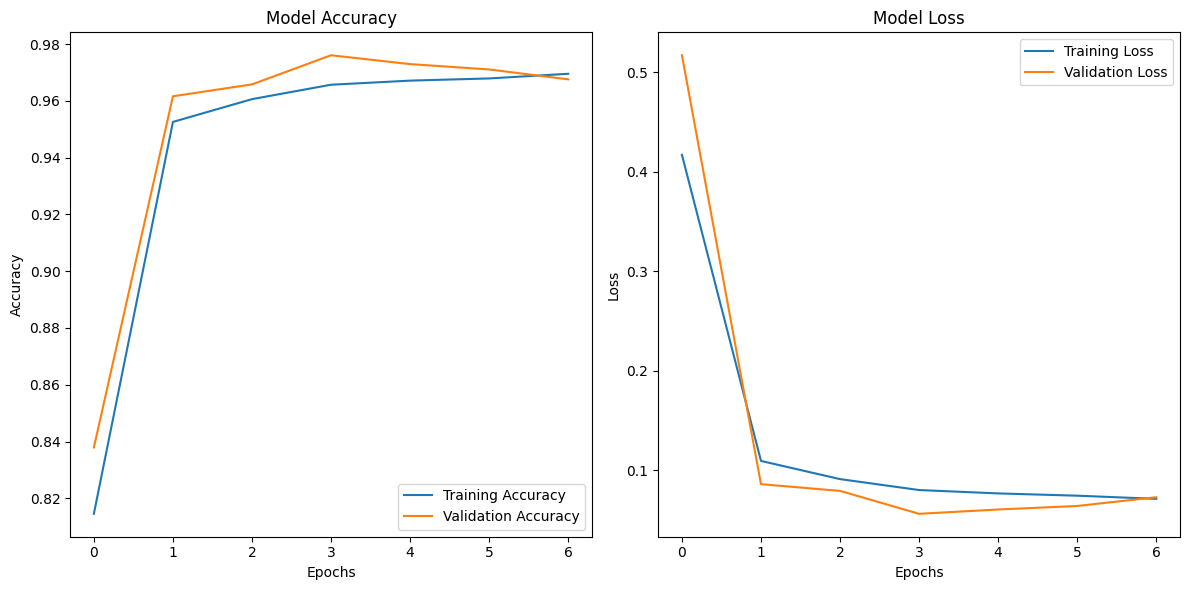

In [88]:
plt.figure(figsize=(12, 6)) 

plt.subplot(1, 2, 1) 
plt.plot(history.history['accuracy'], label='Training Accuracy') 
plt.plot(history.history['val_accuracy'], label='Validation Accuracy') 
plt.title('Model Accuracy') 
plt.xlabel('Epochs') 
plt.ylabel('Accuracy') 
plt.legend() 

plt.subplot(1, 2, 2) 
plt.plot(history.history['loss'], label='Training Loss') 
plt.plot(history.history['val_loss'], label='Validation Loss') 
plt.title('Model Loss') 
plt.xlabel('Epochs') 
plt.ylabel('Loss') 
plt.legend() 
 
plt.tight_layout() 
plt.show()

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     53157
           1       0.98      0.95      0.96     52135
           2       0.97      0.96      0.97     44646
           3       0.99      0.99      0.99     50062

    accuracy                           0.98    200000
   macro avg       0.98      0.98      0.98    200000
weighted avg       0.98      0.98      0.98    200000



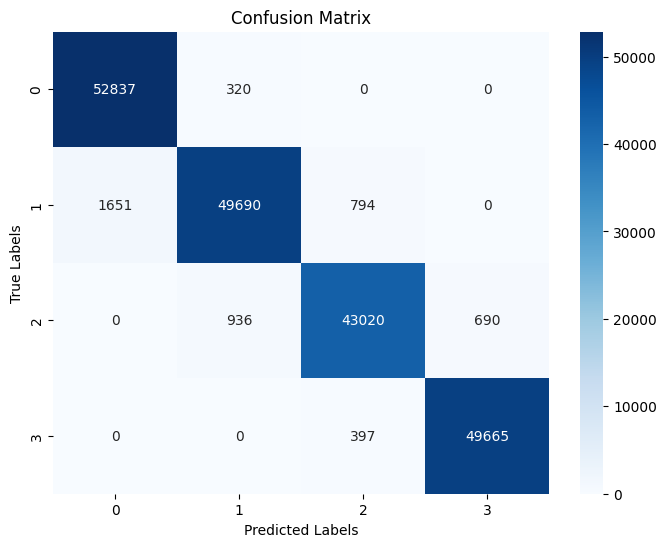

In [102]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_probs = model.predict(x_val)
y_pred = np.argmax(y_pred_probs, axis=1)

print("--- Classification Report ---")
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

### **Deep Neural Network (DNN) reached a stellar 98% global accuracy and outclassing the previous tree-based models. The classification report shows incredibly high and balanced F1-scores (0.96 to 0.99), with the confusion matrix confirming that the model has nearly mastered the dataset; most classes have fewer than 1,000 errors despite the massive 200,000-sample test size. The most "difficult" area remains the overlap between Class 1 and Class 2, though even here, the DNN significantly reduced the leakage compared to Random Forest or CatBoost.**

In [108]:
with open('dnn_model.pkl' , 'wb') as f :
   pickle.dump(model, f)

---------------------------------------------
## **Test**
---------------------------------------------

In [145]:
data_test = pd.read_excel('/kaggle/working/data_for_test.xlsx')
data_test.head()

,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,exercise_hours_per_week,...,ads_clicked_per_day,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,average_session_length_minutes,content_type_preference,preferred_content_theme,age_of_account,engagement_seg
0,20,Male,Australia,Rural,Middle,Full-time employed,High school,Single,No,3.0,...,1,6,2,3,3,13.0,Reels,Travel,6,Power Users
1,36,Male,Canada,Rural,Middle,Retired,Other,Divorced,No,4.3,...,6,160,85,58,71,24.1,Live,Food,13,Passive Users
2,30,Female,United States,Urban,Upper-middle,Freelancer,High school,In a relationship,No,5.5,...,2,19,8,6,12,33.0,Mixed,Tech,6,Power Users
3,27,Male,India,Urban,Lower-middle,Student,Bachelor,In a relationship,No,2.1,...,4,47,28,27,42,14.4,Stories,Food,11,Power Users
4,48,Female,Other,Suburban,Low,Full-time employed,Bachelor,In a relationship,No,4.3,...,11,153,74,72,115,12.3,Mixed,Music,2,Passive Users


In [146]:
d = {'Passive Users': 0, 'Casual Users': 1, 'Regular Users' : 2, 'Power Users' : 3}
data_test['engagement_seg'] = data_test['engagement_seg'].map(d)

In [147]:
original_data_test_cat = data_test.copy()
original_data_test_lgbm = data_test.copy()
original_data_test_rf = data_test.copy()
original_data_test_dnn = data_test.copy()

In [148]:
data_test = data_test.drop('engagement_seg',axis=1)

--------------------------------------------

In [109]:
with open('/kaggle/working/cat_pipeline.pkl','rb') as f : 
    cat_pipeline = pickle.load(f)

In [110]:
new_predictions1 = cat_pipeline.predict(data_test)

In [111]:
new_predictions1.shape

(200, 1)

In [142]:
#new_predictions1 = new_predictions1.ravel()
#new_predictions1.shape

In [112]:
original_data_test_cat['engagement_seg_predicted'] = new_predictions1

In [113]:
original_data_test_cat[['engagement_seg','engagement_seg_predicted']]

,engagement_seg,engagement_seg_predicted
0,3,3
1,0,0
2,3,3
3,3,3
4,0,0
...,...,...
195,1,1
196,1,1
197,2,2
198,1,1


-------------------------------------

In [114]:
with open('/kaggle/working/lgbm_pipeline.pkl','rb') as f : 
    lgbm_pipeline = pickle.load(f)

In [115]:
new_predictions2 = lgbm_pipeline.predict(data_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [116]:
original_data_test_lgbm['engagement_seg_predicted'] = new_predictions2

In [117]:
original_data_test_lgbm[['engagement_seg','engagement_seg_predicted']]

,engagement_seg,engagement_seg_predicted
0,3,3
1,0,0
2,3,3
3,3,3
4,0,0
...,...,...
195,1,1
196,1,2
197,2,2
198,1,1


--------------------------------------------

In [118]:
with open('/kaggle/working/rf_pipeline.pkl','rb') as f : 
    rf_pipeline = pickle.load(f)

In [119]:
new_predictions3 = rf_pipeline.predict(data_test)

In [120]:
original_data_test_rf['engagement_seg_predicted'] = new_predictions3

In [121]:
original_data_test_rf[['engagement_seg','engagement_seg_predicted']]

,engagement_seg,engagement_seg_predicted
0,3,3
1,0,0
2,3,3
3,3,3
4,0,0
...,...,...
195,1,1
196,1,1
197,2,2
198,1,1


---------------------------------

In [149]:
with open('dnn_model.pkl','rb') as f : 
    dnn_model = pickle.load(f)

In [150]:
with open('/kaggle/working/ordinal_encoder.pkl','rb') as f : 
    ordinal_encoder = pickle.load(f)

In [151]:
data_test[cats_cols] = ordinal_encoder.transform(data_test[cats_cols])

In [152]:
with open('/kaggle/working/sclaer.pkl','rb') as f : 
    scaler = pickle.load(f)

In [153]:
data_test[num_cols] = scaler.transform(data_test[num_cols])

In [154]:
new_predictions4 = dnn_model.predict(data_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [155]:
final_predictions = np.argmax(new_predictions4, axis=1)

In [156]:
final_predictions.shape

(200,)

In [157]:
original_data_test_dnn['engagement_seg_predicted'] = final_predictions

In [159]:
original_data_test_dnn[['engagement_seg','engagement_seg_predicted']]

,engagement_seg,engagement_seg_predicted
0,3,3
1,0,0
2,3,3
3,3,3
4,0,0
...,...,...
195,1,1
196,1,2
197,2,2
198,1,1


In [160]:
# original_data_test_dnn.to_excel('prediction_data.xlsx',index=False)

----------------------------------


# <center><strong>Conclusion</strong></center>
--------------------------------------------
### **The results reveal a clear disparity in analytical capability among the four models, with the Deep Neural Network (DNN) emerging as the top performer at 98% accuracy. It excelled in defining precise decision boundaries and minimizing overlap between the middle classes. LightGBM follows closely in second place with a strong 96%, making it the ideal choice if training speed and interpretability are priorities. In contrast, CatBoost (91%) and Random Forest (85%) struggled more with the complex, non-linear patterns in the data, particularly when distinguishing between Class 1 and Class 2. Overall, deep learning and boosting algorithms demonstrated a qualitative edge over traditional random forests for this task, suggesting the data contains intricate relationships that require high-capacity models.**

---------------------------------------

In [ ]:
# !jupyter nbconvert --to html "social-media-user-classification.ipynb"

[NbConvertApp] Converting notebook social-media-user-classification.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 99 image(s).
[NbConvertApp] Writing 6808118 bytes to social-media-user-classification.html
